### Nhập dữ liệu

In [99]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import lognorm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import kurtosis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Tổng quan bộ dữ liệu

In [100]:
# 🔹 Đọc dữ liệu
df = pd.read_csv('hotel_bookings.csv')
print(df.shape)
print(df.info())

# 🔹 Xem 5 dòng đầu tiên
df.head(5)

(119390, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  mea

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


#### Thuộc tính số (Numerical Attributes)

- is_canceled: Cho biết phòng được đặt có bị hủy không (1 = Hủy, 0 = Không hủy).
- lead_time: Số ngày giữa thời điểm đặt phòng và ngày đến.
- arrival_date_year: Năm của ngày đến.
- arrival_date_week_number: Tuần trong năm của ngày đến.
- arrival_date_day_of_month: Ngày trong tháng của ngày đến.
- stays_in_weekend_nights: Số đêm cuối tuần (Thứ Bảy, Chủ Nhật) khách ở hoặc đặt.
- stays_in_week_nights: Số đêm trong tuần (Thứ Hai–Thứ Sáu) khách ở hoặc đặt.
- adults: Số lượng người lớn trong đặt phòng.
- children: Số lượng trẻ em trong đặt phòng.
- babies: Số lượng trẻ sơ sinh trong đặt phòng.
- previous_cancellations: Số lần đặt phòng trước đó bị hủy của khách.
- previous_bookings_not_canceled: Số lần đặt phòng trước đó không bị hủy.
- booking_changes: Số lần thay đổi trong đặt phòng.
- days_in_waiting_list: Số ngày đặt phòng nằm trong danh sách chờ.
- adr: Giá trung bình mỗi đêm (Average Daily Rate).
- required_car_parking_spaces: Số chỗ đậu xe yêu cầu.
- total_of_special_requests: Tổng số yêu cầu đặc biệt từ khách.

#### Thuộc tính phân loại (Categorical Attributes)

- hotel: Loại khách sạn (ví dụ: City Hotel, Resort Hotel).
- arrival_date_month: Tháng của ngày đến.
- meal: Loại gói ăn được đặt.
- country: Quốc gia xuất xứ của khách.
- market_segment: Phân khúc thị trường (ví dụ: Online TA, Groups).
- distribution_channel: Kênh đặt phòng (ví dụ: Direct, Corporate).
- is_repeated_guest: Khách đã từng ở khách sạn trước đây (1 = Có, 0 = Không).
- reserved_room_type: Loại phòng được đặt.
- assigned_room_type: Loại phòng được sắp xếp.
- deposit_type: Loại đặt cọc (ví dụ: No Deposit, Refundable).
- customer_type: Loại khách hàng (ví dụ: Transient, Group).
- reservation_status: Trạng thái hiện tại của đặt phòng (Canceled, No-Show, Checked-Out).
- reservation_status_date: Ngày cập nhật trạng thái gần nhất.

#### Thuộc tính bổ sung (Additional Attributes)

- agent: ID của đại lý du lịch.
- company: ID công ty thực hiện đặt phòng.


##### Các cột 'is_repeated_guest' và 'is_canceled' nên có kiểu dữ liệu boolean. Tuy nhiên, kết quả ở ô trên cho thấy chúng đang có kiểu dữ liệu integer. Vì vậy, cần chuyển kiểu dữ liệu của chúng sang bool.

In [101]:
df[['is_repeated_guest','is_canceled']] = df[['is_repeated_guest','is_canceled']].astype(bool)
print(df['is_repeated_guest'].dtype)

bool


### Kiểu tra bất thường trong bộ dữ liệu


#### Kiểm tra missing value :

In [102]:
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

 **Thấy được**
Các cột có missing values:
`country`: 488 missing values
`agent`: 16340 missing values
`company`: 112593 missing values

#### Kiểm tra trùng lặp : 

In [103]:
# Tìm các hàng trùng lặp
duplicated_rows = df[df.duplicated()]

print(f"Tổng số hàng trùng lặp: {len(duplicated_rows)}")
print("\nSố lượng giá trị không null theo từng cột:")
print(duplicated_rows.count())

Tổng số hàng trùng lặp: 31994

Số lượng giá trị không null theo từng cột:
hotel                             31994
is_canceled                       31994
lead_time                         31994
arrival_date_year                 31994
arrival_date_month                31994
arrival_date_week_number          31994
arrival_date_day_of_month         31994
stays_in_weekend_nights           31994
stays_in_week_nights              31994
adults                            31994
children                          31994
babies                            31994
meal                              31994
country                           31958
market_segment                    31994
distribution_channel              31994
is_repeated_guest                 31994
previous_cancellations            31994
previous_bookings_not_canceled    31994
reserved_room_type                31994
assigned_room_type                31994
booking_changes                   31994
deposit_type                      31994
agent 

#### Kiểm tra outlier

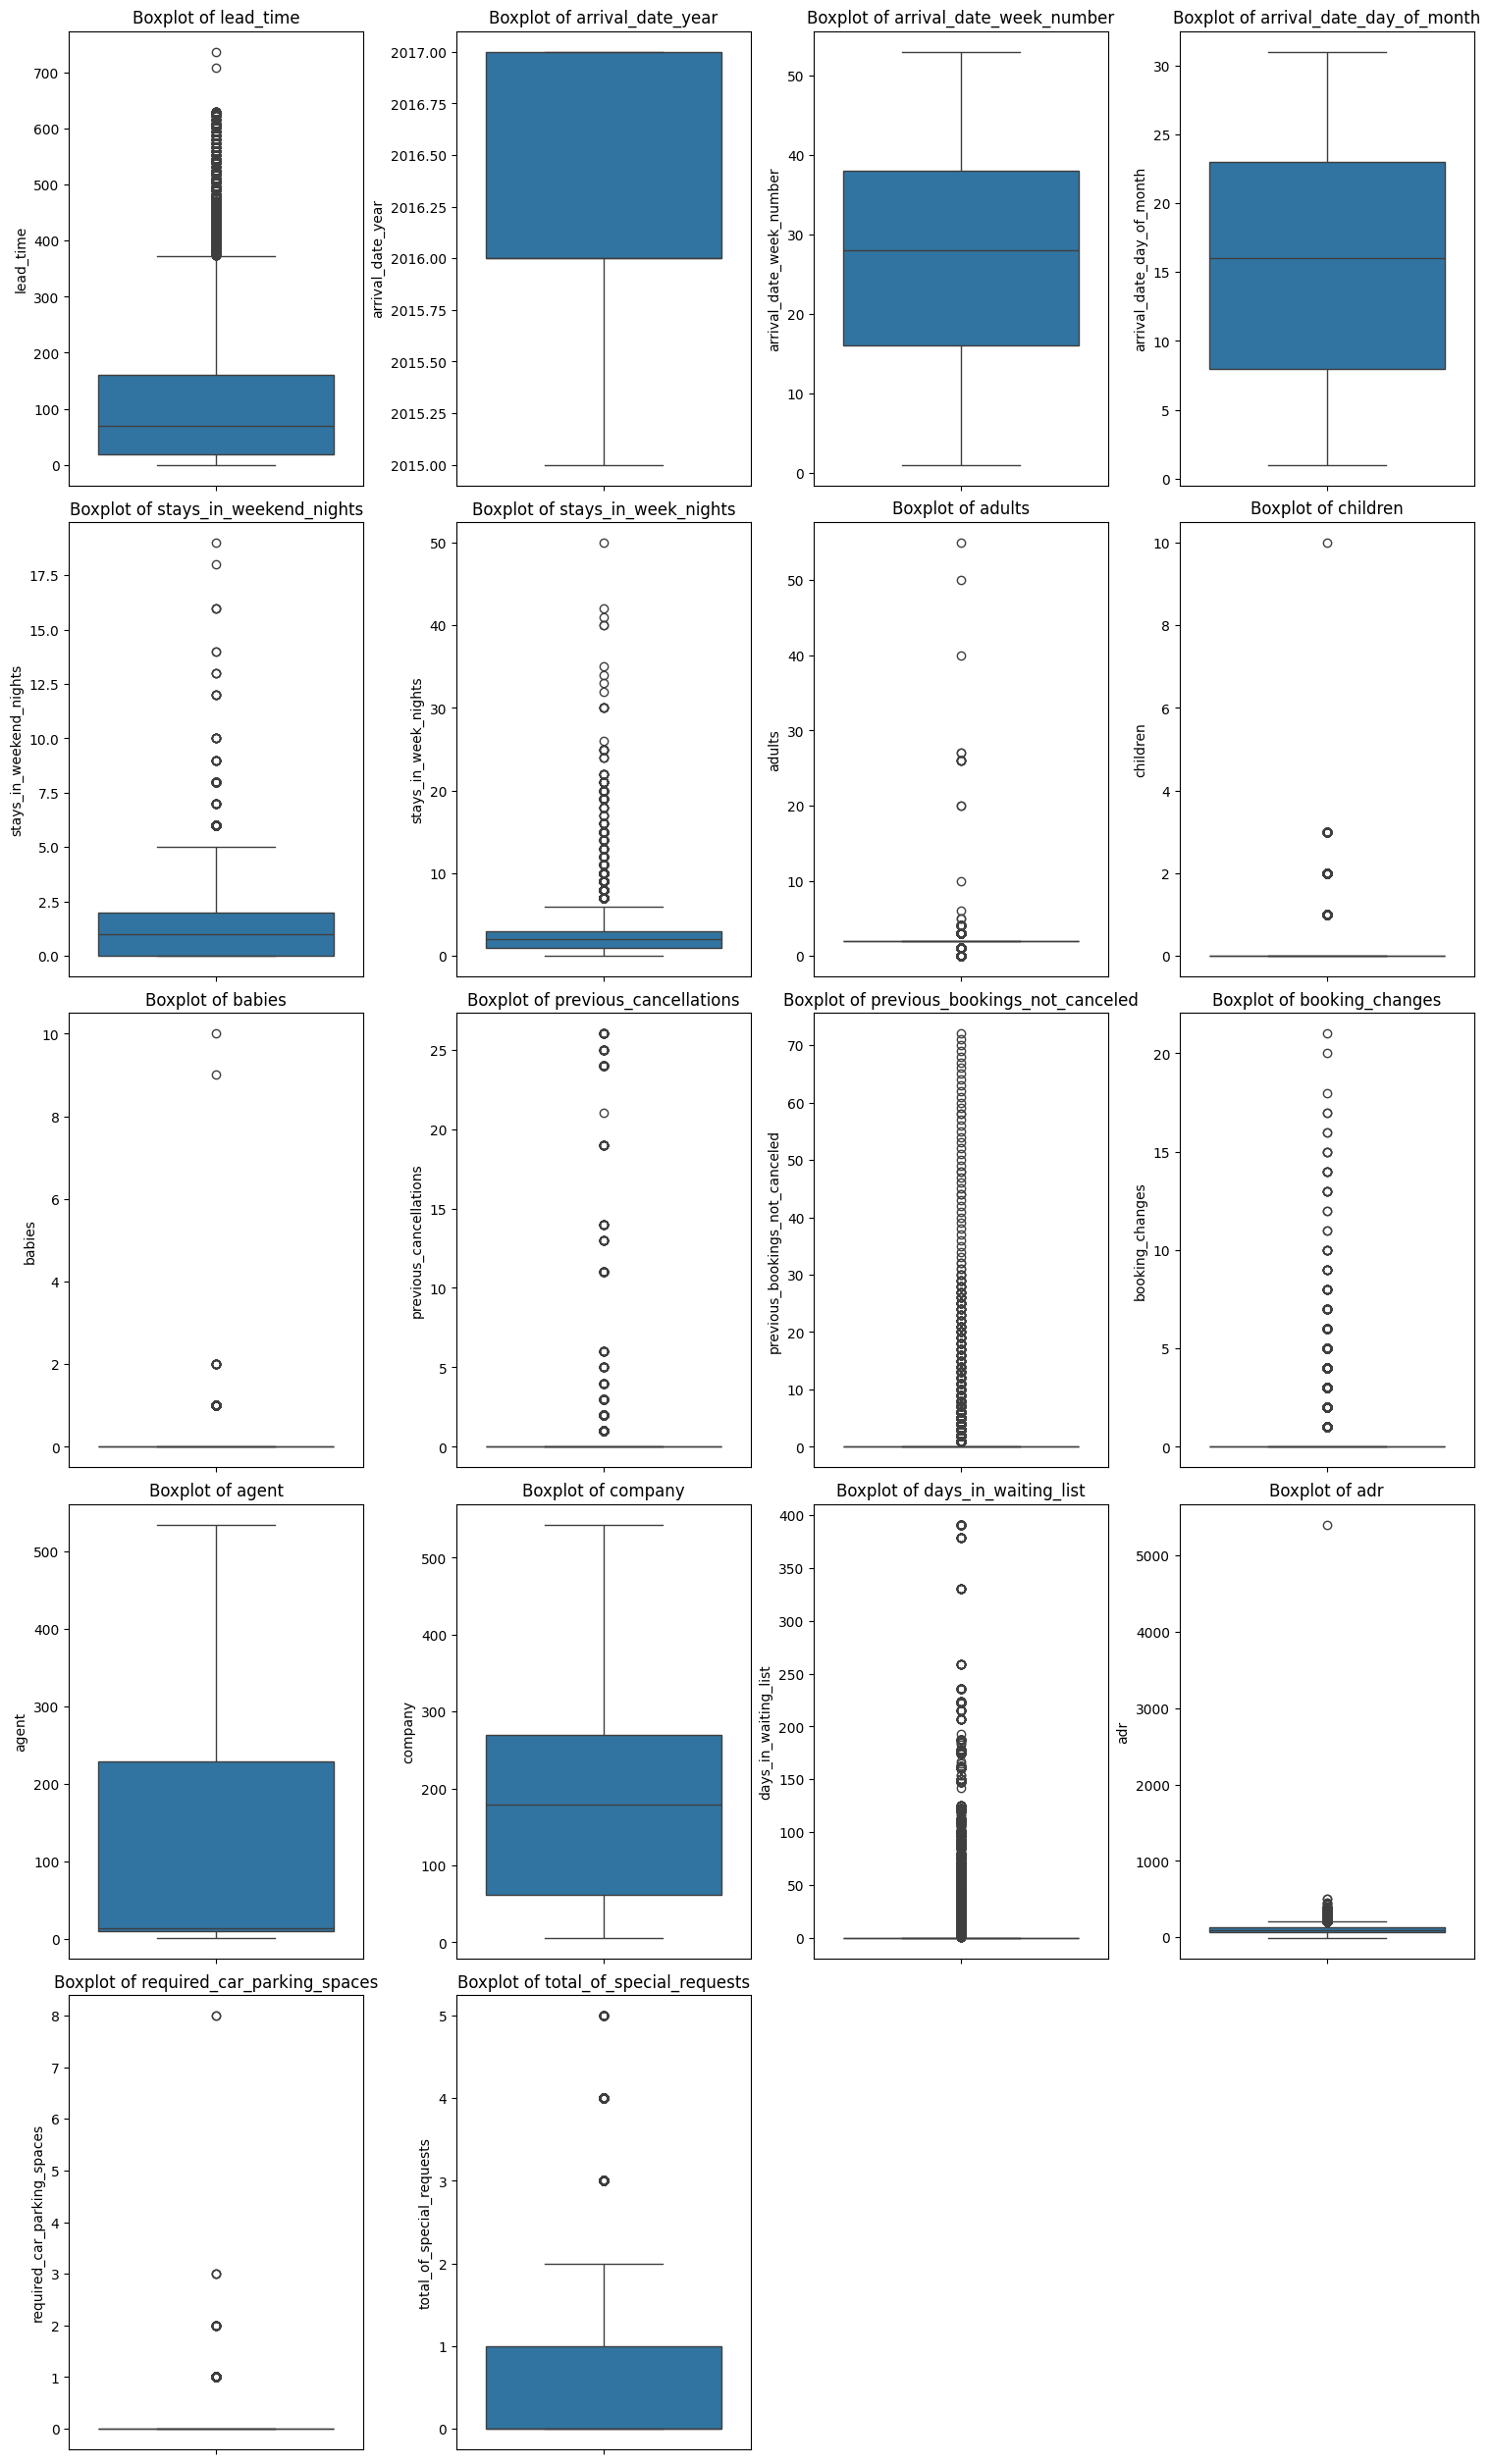

In [104]:
numeric_cols = df.select_dtypes(include=['number']).columns

# Define rows and columns based on the number of numeric columns
num_plots = len(numeric_cols)
columns = 4
rows = math.ceil(num_plots / columns)  # Calculate the number of rows needed

# Create subplots grid
fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows), constrained_layout=True)

# Flatten axes array for easy indexing
axes = axes.flatten()

# Plot each numeric column
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel("")  # Remove x-label for better spacing

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Delete extra axes

# Show the plots
plt.show()

### Phân tích đơn biến (Univariate analysis): 


##### Thống kê tóm tắt các cột có định dạng giá trị là số


In [105]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
print(df[numeric_columns].describe())

           lead_time  arrival_date_year  arrival_date_week_number  \
count  119390.000000      119390.000000             119390.000000   
mean      104.011416        2016.156554                 27.165173   
std       106.863097           0.707476                 13.605138   
min         0.000000        2015.000000                  1.000000   
25%        18.000000        2016.000000                 16.000000   
50%        69.000000        2016.000000                 28.000000   
75%       160.000000        2017.000000                 38.000000   
max       737.000000        2017.000000                 53.000000   

       arrival_date_day_of_month  stays_in_weekend_nights  \
count              119390.000000            119390.000000   
mean                   15.798241                 0.927599   
std                     8.780829                 0.998613   
min                     1.000000                 0.000000   
25%                     8.000000                 0.000000   
50%         

##### **Xu hướng trung tâm**  :  


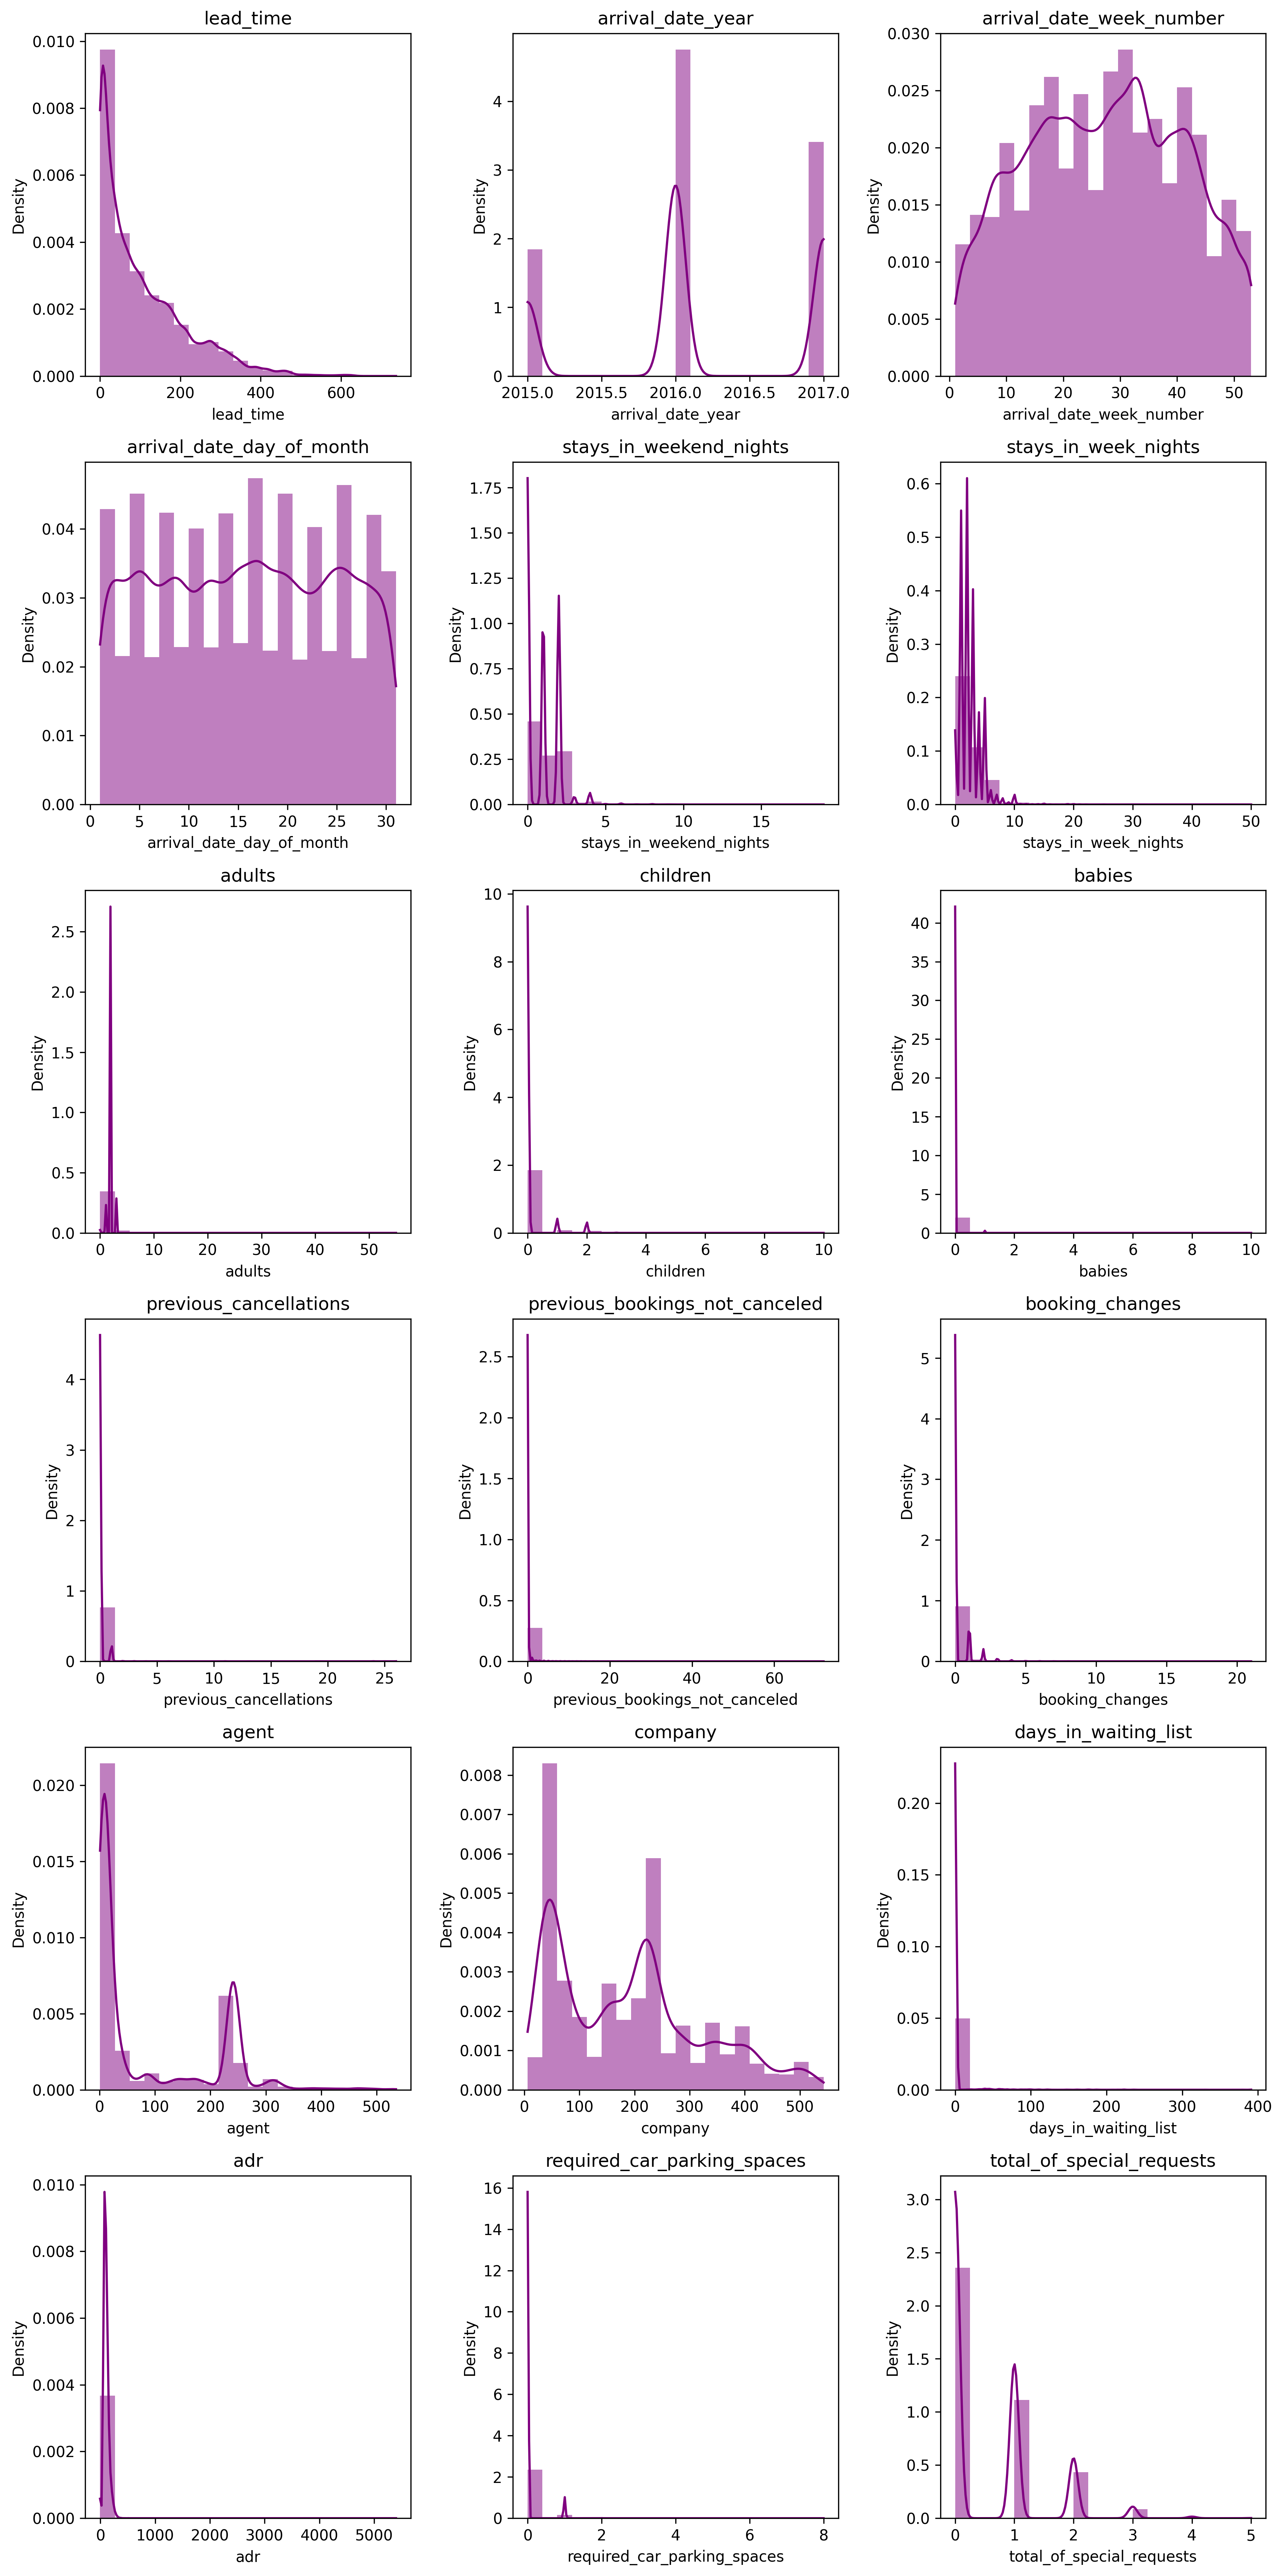

In [106]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the number of rows and columns needed
num_plots = len(numeric_columns)
cols = 3  # Fixed number of columns
rows = int(np.ceil(num_plots / cols))  # Dynamically calculate the number of rows

plt.figure(figsize=(12, rows * 4), dpi=300)

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(rows, cols, i)
    try:
        sns.histplot(df[col].dropna(), kde=True, bins=20, color='Purple', stat='density', linewidth=0)
        plt.title(col)
    except Exception as e:
        plt.text(0.5, 0.5, f"Lỗi: {e}", ha='center', va='center')
    plt.tight_layout()

plt.show()

**Lead Time (Thời gian đặt trước)**
- Phân bố của lead time lệch phải, cho thấy hầu hết các đặt phòng được thực hiện gần ngày đến, trong khi một số ít được đặt trước rất lâu. Điều này gợi ý rằng phần lớn khách lập kế hoạch ở phút chót, nhưng vẫn có một số khách lên kế hoạch từ trước.

**Arrival Date Year (Năm đến)**
- Phân bố năm đến tập trung vào một số năm cụ thể, với xu hướng tăng nhẹ theo thời gian. Điều này có thể phản ánh sự gia tăng tổng thể trong số lượng đặt phòng hoặc các biến động theo mùa trong hành vi du lịch.

**Stays in Weekend Nights (Số đêm cuối tuần)**
- Phân bố lệch phải, với hầu hết khách chỉ lưu trú ngắn trong cuối tuần. Một số ít khách kéo dài kỳ nghỉ cuối tuần, có thể do dịp đặc biệt hoặc kỳ nghỉ dài hơn.

**Stays in Week Nights (Số đêm trong tuần)**
- Tương tự như cuối tuần, phân bố cũng lệch phải. Hầu hết khách lưu trú ngắn trong tuần, một số ít chọn ở lâu hơn, có thể vì công việc hoặc nghỉ dưỡng.

**Adults, Children, and Babies (Người lớn, trẻ em, và em bé)**
- Hầu hết đặt phòng chỉ có người lớn, ít đặt có trẻ em hoặc em bé. Điều này cho thấy đa số khách là cặp đôi hoặc đi một mình.

**Previous Cancellations and Bookings Not Canceled (Hủy trước và đặt trước chưa hủy)**
- Phân bố lệch phải, cho thấy hầu hết khách có lịch sử đặt phòng “sạch” với ít hủy. Một số ít khách có tỷ lệ hủy cao, có thể là vấn đề cần lưu ý trong quản lý doanh thu.

**Booking Changes (Thay đổi đặt phòng)**
- Phân bố lệch phải, hầu hết khách ít hoặc không thay đổi đặt phòng. Một số ít khách thay đổi nhiều lần, thể hiện sự không chắc chắn hoặc linh hoạt trong kế hoạch du lịch.

**Kết luận**
- Lệch phải của lead time và số đêm lưu trú cho thấy hầu hết khách thích các chuyến đi ngắn và linh hoạt.
- Sự xuất hiện của outliers trong số đêm lưu trú và thay đổi đặt phòng gợi ý cần marketing nhắm mục tiêu hoặc chính sách đặt phòng linh hoạt.
- Phân bố người lớn, trẻ em, em bé nhấn mạnh tầm quan trọng của việc phục vụ khách trưởng thành, đồng thời cân nhắc các lựa chọn thân thiện với gia đình.




In [107]:
# Xóa trùng lặp
df_cleaned = df.drop_duplicates()

# Kiểm tra lại
print(f"Số hàng trùng còn lại: {df_cleaned.duplicated().sum()}")

# Xem thông tin DataFrame sau khi làm sạch
print(df_cleaned.info())

Số hàng trùng còn lại: 0
<class 'pandas.core.frame.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  bool   
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87392 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal       

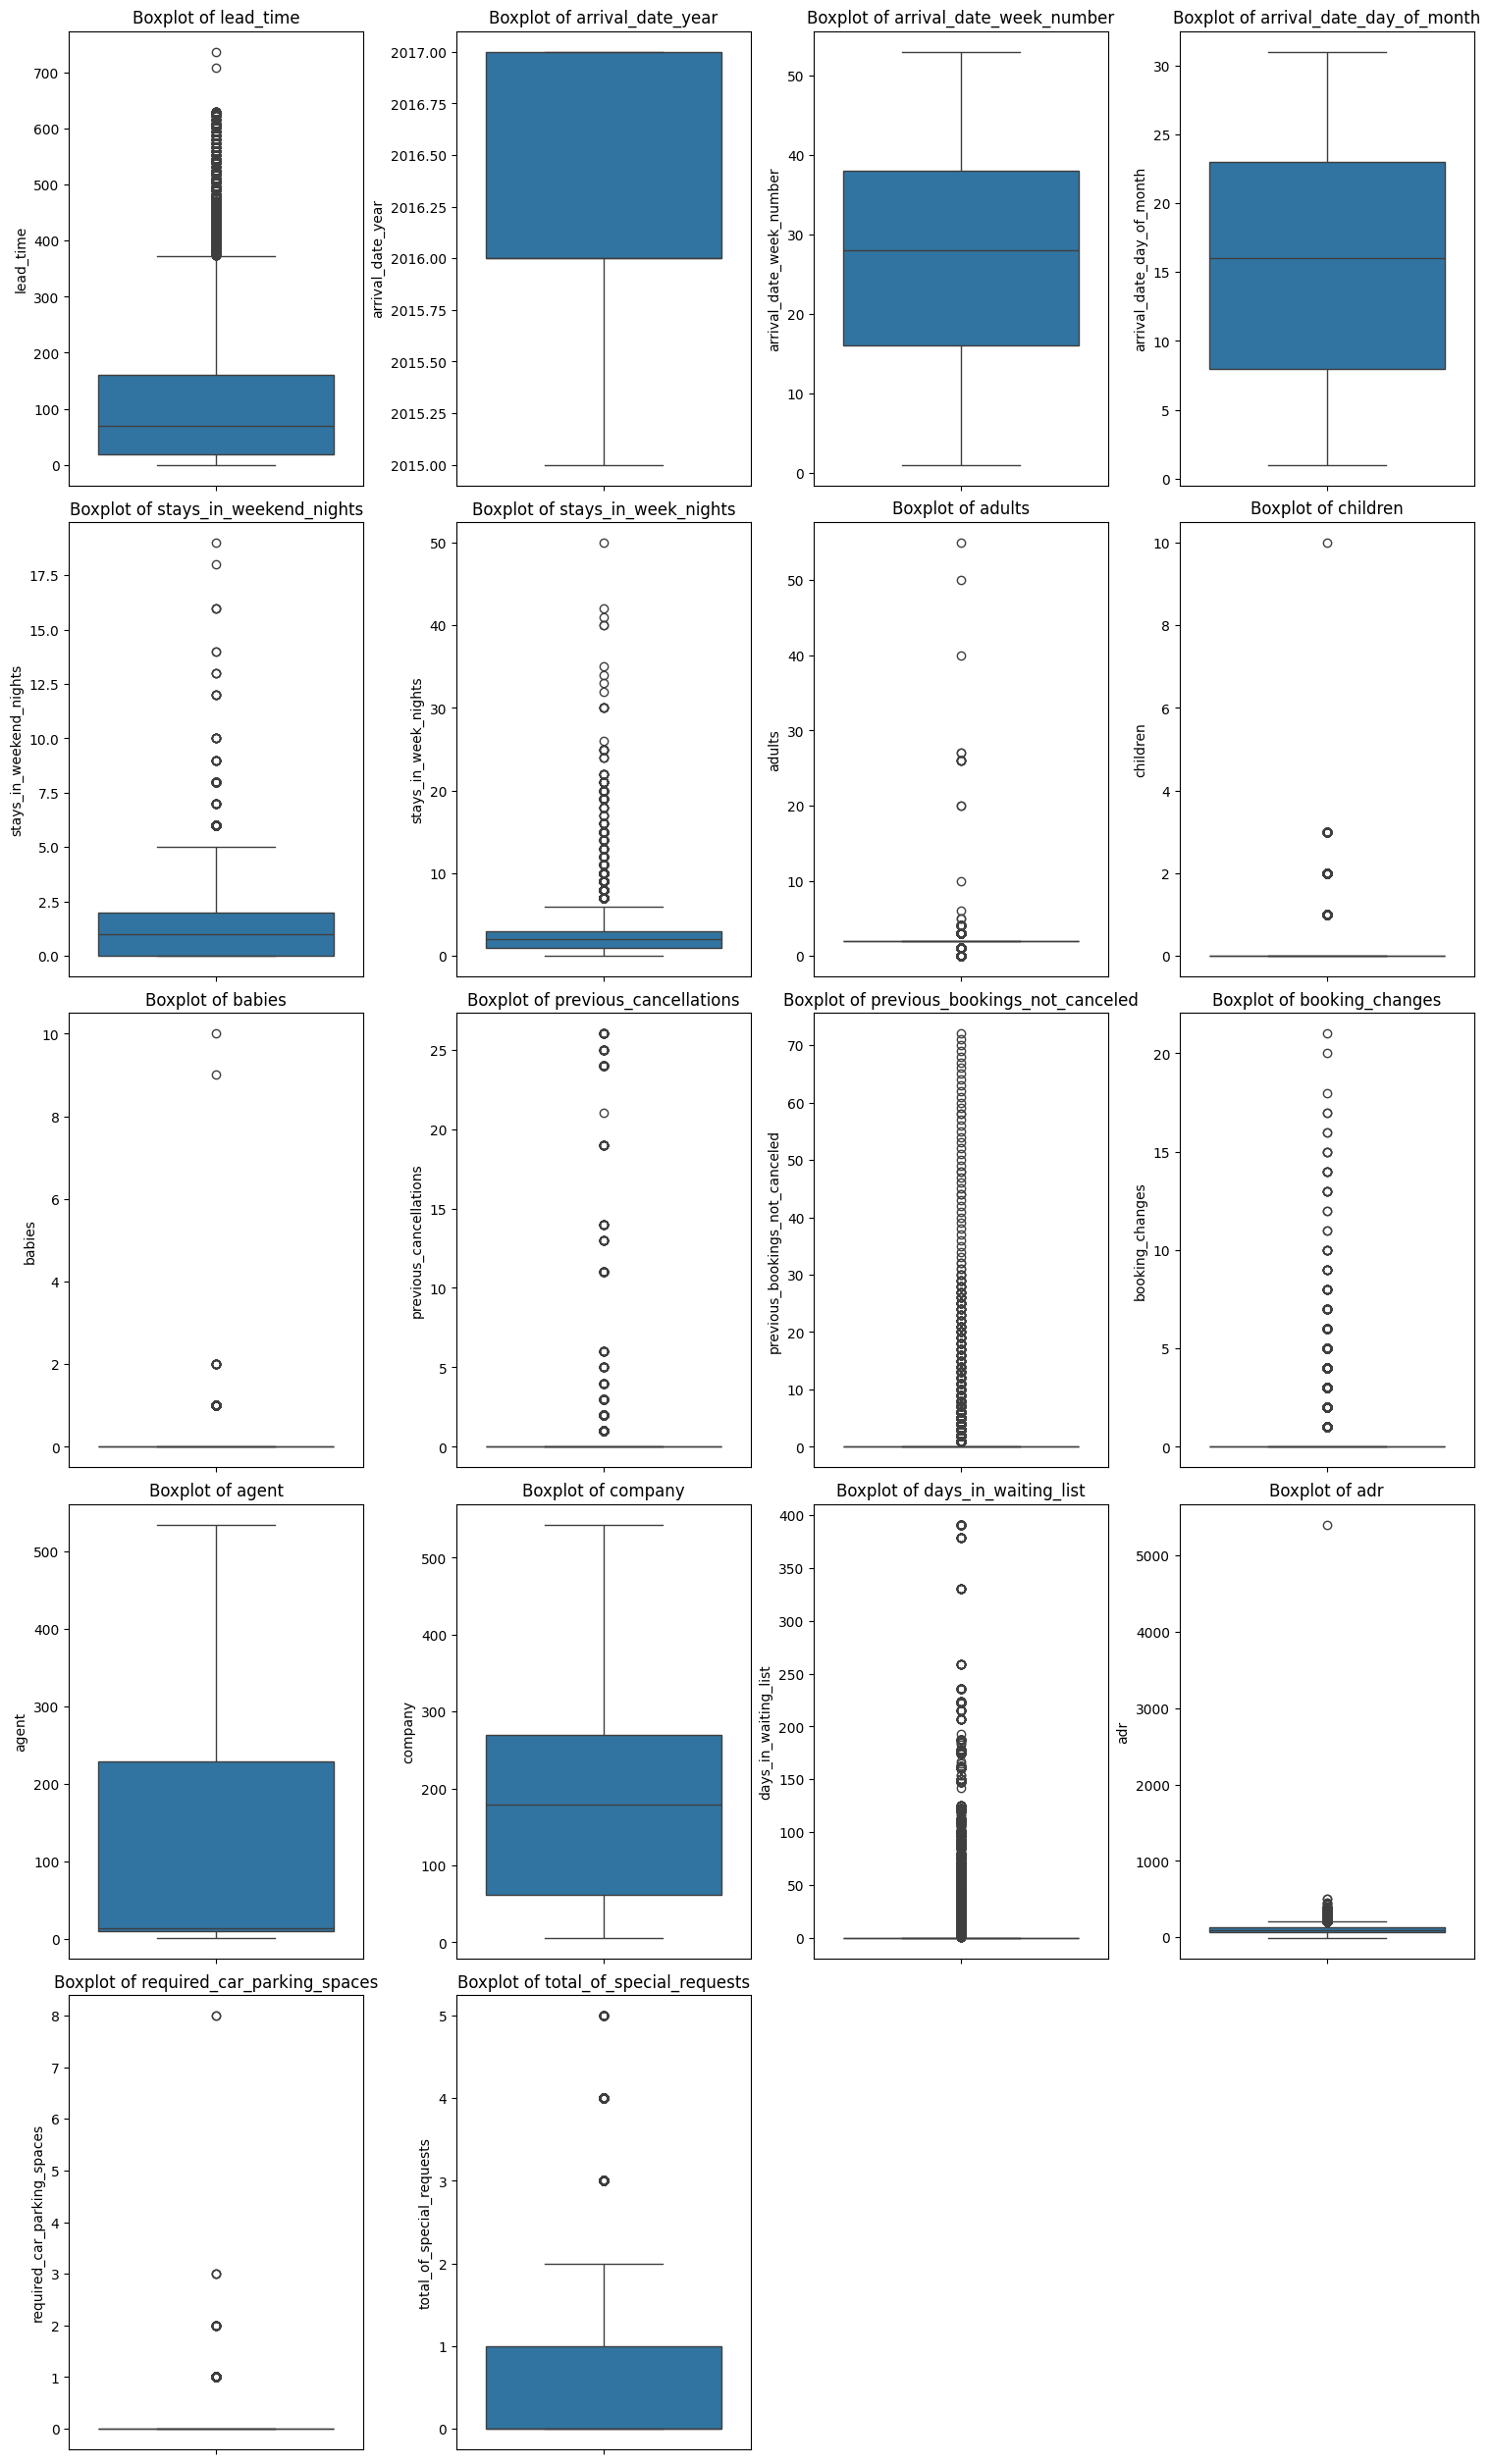

In [108]:
numeric_cols = df.select_dtypes(include=['number']).columns

# Define rows and columns based on the number of numeric columns
num_plots = len(numeric_cols)
columns = 4
rows = math.ceil(num_plots / columns)  # Calculate the number of rows needed

# Create subplots grid
fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows), constrained_layout=True)

# Flatten axes array for easy indexing
axes = axes.flatten()

# Plot each numeric column
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel("")  # Remove x-label for better spacing

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Delete extra axes

# Show the plots
plt.show()

#### Xử lí Oulier

**Xử lý ngoại lệ và giá trị bất thường trong dữ liệu đặt phòng:**

- **Stays in Week Nights:** Quan sát có giá trị >50 đêm. Xử lý bằng cách giới hạn tối đa 30 đêm và có thể phân loại ngắn/trung/dài.  
- **Stays in Weekend Nights:** Quan sát có giá trị >17 đêm. Giới hạn tối đa 10 đêm.  
- **Adults, Children, Babies:** Quan sát có giá trị bất thường (adults >50, children >10). Lọc các giá trị không hợp lý (adults ≤10, children ≤10, babies ≤5) và điền giá trị thiếu (children = median, babies = 0).  
- **Previous Cancellations & Previous Bookings Not Canceled:** Quan sát có giá trị >20. Giới hạn tối đa 10, đồng thời phân tích các trường hợp hủy/đặt nhiều.  
- **Booking Changes:** Một số booking có >10 thay đổi. Giới hạn tối đa 5 và kiểm tra nguyên nhân các booking thay đổi nhiều.  
- **Days in Waiting List:** Quan sát có giá trị >300 ngày. Giới hạn tối đa 200 ngày và phân loại ngắn/trung/dài cho phân tích.

In [109]:
df['stays_in_week_nights'] = np.where(df['stays_in_week_nights'] > 30, 30, df['stays_in_week_nights'])
df['stays_in_weekend_nights'] = np.where(df['stays_in_weekend_nights'] > 10, 10, df['stays_in_weekend_nights'])

df = df[(df['adults'] <= 10) & (df['children'] <= 10) & (df['babies'] <= 5)]
df.fillna({'children': df['children'].median(), 'babies': 0}, inplace=True)

df['previous_cancellations'] = np.where(df['previous_cancellations'] > 10, 10, df['previous_cancellations'])
df['previous_bookings_not_canceled'] = np.where(df['previous_bookings_not_canceled'] > 10, 10, df['previous_bookings_not_canceled'])
df['booking_changes'] = np.where(df['booking_changes'] > 5, 5, df['booking_changes'])
df['days_in_waiting_list'] = np.where(df['days_in_waiting_list'] > 200, 200, df['days_in_waiting_list'])

##### Kết quả phân tích đơn biến (Univariate Analysis)

Các phát hiện chính như sau:

- Phân bố của biến hủy đặt phòng (cancellation) theo giá trị True/False: Thống kê cho thấy tỉ lệ khách hủy so với không hủy. Giúp hiểu được biến mục tiêu (target variable) có cân bằng hay lệch về một phía.

- Biến mục tiêu “lead time” bị lệch phải mạnh (positively skewed): Giá trị của “lead time” (số giờ trước khi khách đến thực tế) phần lớn là nhỏ, nhưng có một số giá trị lớn kéo dài về bên phải. Điều này làm trung bình bị kéo lên, không phản ánh đúng “giá trị điển hình”.

- Đường phân bố của lead time có hình Platykurtic (đỉnh thấp, rộng và đuôi ngắn, mỏng). Điều này có nghĩa là dữ liệu phân tán rộng, ít tập trung quanh trung bình, các giá trị cực đoan (outliers) ít hơn so với phân bố chuẩn.

- Dữ liệu Lead Time theo giờ gần giống phân bố log-normal hơn là phân bố chuẩn. Điều này phù hợp với dữ liệu thời gian, vốn không thể âm và thường có một số giá trị rất lớn (long tail).

##### Thống kê tóm tắt các cột có định dạng giá trị là số


In [110]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
print(df[numeric_columns].describe())

           lead_time  arrival_date_year  arrival_date_week_number  \
count  119372.000000      119372.000000             119372.000000   
mean      103.992452        2016.156720                 27.163916   
std       106.842818           0.707394                 13.605375   
min         0.000000        2015.000000                  1.000000   
25%        18.000000        2016.000000                 16.000000   
50%        69.000000        2016.000000                 28.000000   
75%       160.000000        2017.000000                 38.000000   
max       737.000000        2017.000000                 53.000000   

       arrival_date_day_of_month  stays_in_weekend_nights  \
count              119372.000000            119372.000000   
mean                   15.799023                 0.927018   
std                     8.780806                 0.992496   
min                     1.000000                 0.000000   
25%                     8.000000                 0.000000   
50%         

##### **Xu hướng trung tâm**  :  
 

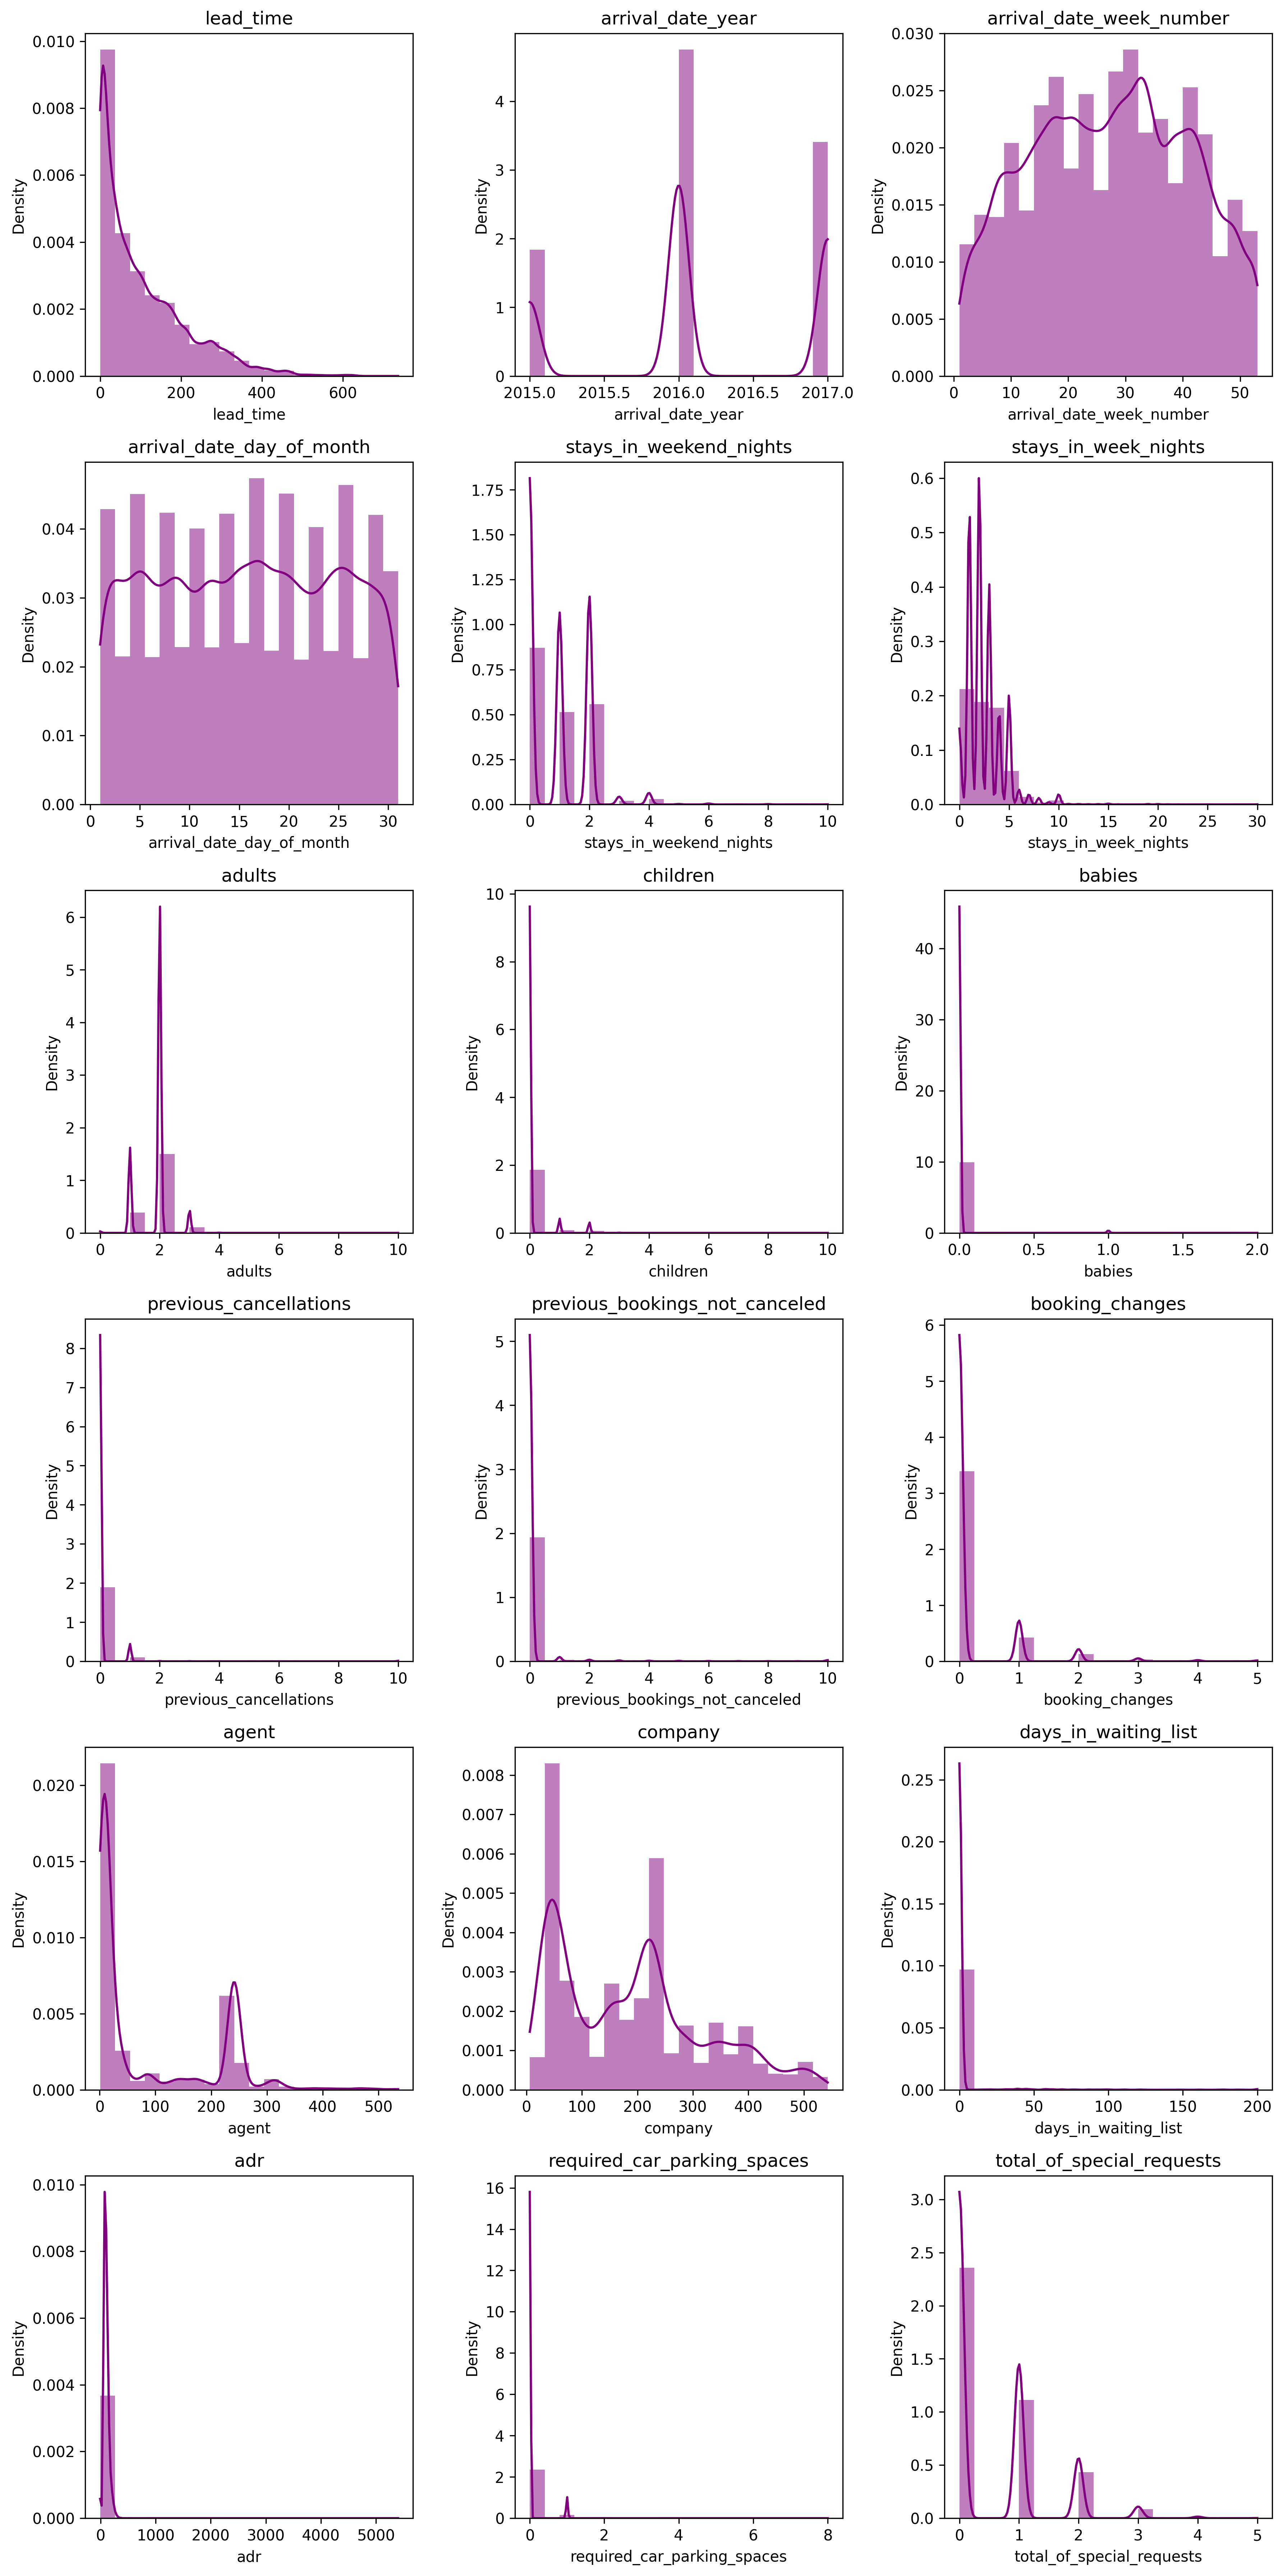

In [111]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the number of rows and columns needed
num_plots = len(numeric_columns)
cols = 3  # Fixed number of columns
rows = int(np.ceil(num_plots / cols))  # Dynamically calculate the number of rows

plt.figure(figsize=(12, rows * 4), dpi=300)

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(rows, cols, i)
    try:
        sns.histplot(df[col].dropna(), kde=True, bins=20, color='Purple', stat='density', linewidth=0)
        plt.title(col)
    except Exception as e:
        plt.text(0.5, 0.5, f"Lỗi: {e}", ha='center', va='center')
    plt.tight_layout()

plt.show()

**Lead Time (Thời gian đặt trước)**
- Phân bố của lead time lệch phải, cho thấy hầu hết các đặt phòng được thực hiện gần ngày đến, trong khi một số ít được đặt trước rất lâu. Điều này gợi ý rằng phần lớn khách lập kế hoạch ở phút chót, nhưng vẫn có một số khách lên kế hoạch từ trước.

**Arrival Date Year (Năm đến)**
- Phân bố năm đến tập trung vào một số năm cụ thể, với xu hướng tăng nhẹ theo thời gian. Điều này có thể phản ánh sự gia tăng tổng thể trong số lượng đặt phòng hoặc các biến động theo mùa trong hành vi du lịch.

**Stays in Weekend Nights (Số đêm cuối tuần)**
- Phân bố lệch phải, với hầu hết khách chỉ lưu trú ngắn trong cuối tuần. Một số ít khách kéo dài kỳ nghỉ cuối tuần, có thể do dịp đặc biệt hoặc kỳ nghỉ dài hơn.

**Stays in Week Nights (Số đêm trong tuần)**
- Tương tự như cuối tuần, phân bố cũng lệch phải. Hầu hết khách lưu trú ngắn trong tuần, một số ít chọn ở lâu hơn, có thể vì công việc hoặc nghỉ dưỡng.

**Adults, Children, and Babies (Người lớn, trẻ em, và em bé)**
- Hầu hết đặt phòng chỉ có người lớn, ít đặt có trẻ em hoặc em bé. Điều này cho thấy đa số khách là cặp đôi hoặc đi một mình.

**Previous Cancellations and Bookings Not Canceled (Hủy trước và đặt trước chưa hủy)**
- Phân bố lệch phải, cho thấy hầu hết khách có lịch sử đặt phòng “sạch” với ít hủy. Một số ít khách có tỷ lệ hủy cao, có thể là vấn đề cần lưu ý trong quản lý doanh thu.

**Booking Changes (Thay đổi đặt phòng)**
- Phân bố lệch phải, hầu hết khách ít hoặc không thay đổi đặt phòng. Một số ít khách thay đổi nhiều lần, thể hiện sự không chắc chắn hoặc linh hoạt trong kế hoạch du lịch.

**Kết luận**
- Lệch phải của lead time và số đêm lưu trú cho thấy hầu hết khách thích các chuyến đi ngắn và linh hoạt.
- Sự xuất hiện của outliers trong số đêm lưu trú và thay đổi đặt phòng gợi ý cần marketing nhắm mục tiêu hoặc chính sách đặt phòng linh hoạt.
- Phân bố người lớn, trẻ em, em bé nhấn mạnh tầm quan trọng của việc phục vụ khách trưởng thành, đồng thời cân nhắc các lựa chọn thân thiện với gia đình.




In [112]:
df['arrival_date_month'].value_counts()

arrival_date_month
August       13873
July         12661
May          11791
October      11155
April        11089
June         10939
September    10500
March         9794
February      8068
November      6794
December      6780
January       5928
Name: count, dtype: int64

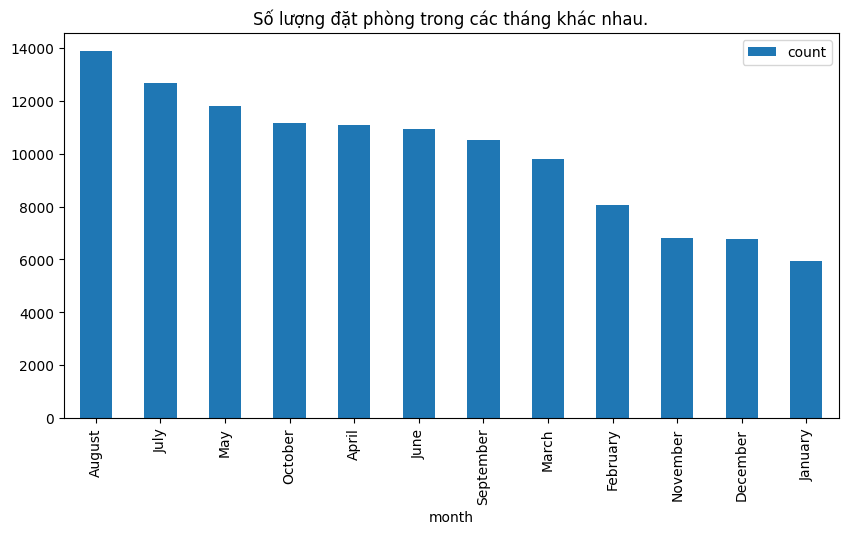

In [113]:
df['arrival_date_month'].value_counts().plot(kind = 'bar', figsize=(10,5))
plt.title('Số lượng đặt phòng trong các tháng khác nhau.')
plt.xlabel('month')
plt.legend()
plt.show()

#### Nhận xét
- Giai đoạn đặt phòng cao điểm: Tháng 8 có số lượng đặt phòng cao nhất, theo sau là tháng 7 và tháng 5. Những tháng này có thể là mùa cao điểm, có khả năng do kỳ nghỉ hè hoặc các sự kiện đặc biệt làm nhu cầu tăng mạnh.

- Các tháng như tháng 10, tháng 4 và tháng 6 có lượng đặt phòng ổn định và ở mức trung bình. Điều này cho thấy nhu cầu tương đối đều nhưng không đạt mức cao điểm.

- Giai đoạn đặt phòng thấp: Tháng 1 có số lượng đặt phòng thấp nhất, theo sau là tháng 12 và tháng 11. Đây có thể là mùa thấp điểm, có thể do thời tiết lạnh, kỳ nghỉ lễ hoặc các yếu tố khác làm giảm hoạt động đặt phòng.

### Khoảng giá trị độ lệch (Skewness)

In [114]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns 
df[numeric_columns].skew()

lead_time                          1.346998
arrival_date_year                 -0.232780
arrival_date_week_number          -0.009771
arrival_date_day_of_month         -0.002121
stays_in_weekend_nights            1.180679
stays_in_week_nights               2.591702
adults                            -0.425756
children                           4.112308
babies                            11.721263
previous_cancellations            15.616334
previous_bookings_not_canceled    10.104925
booking_changes                    3.684595
agent                              1.089325
company                            0.601600
days_in_waiting_list               9.134121
adr                               10.537316
required_car_parking_spaces        4.162868
total_of_special_requests          1.349128
dtype: float64

#### Diễn giải về skewness (độ lệch phân phối)

- Skewness dương (positively skewed): phần lớn biến có đuôi kéo dài bên phải → có outliers lớn.

- Skewness âm (negatively skewed): một số biến có phần lớn giá trị cao.

- Gần đối xứng: vài biến phân bố đều, không thiên lệch rõ rệt.

Ta có:

- Lead Time (1.347): Phân phối lệch phải, nghĩa là phần lớn đặt phòng có thời gian chờ ngắn, nhưng vẫn có một số đặt phòng được thực hiện từ rất sớm.

- Arrival Date Year (-0.233): Phân phối hơi lệch trái, cho thấy dữ liệu có tỷ lệ của các năm gần đây nhiều hơn các năm cũ.

- Arrival Date Week Number (-0.010): Phân phối gần như đối xứng, nghĩa là đặt phòng được trải đều qua các tuần trong năm.

- Arrival Date Day of Month (-0.002): Phân phối gần như đối xứng, cho thấy số lượng đặt phòng được phân bố đồng đều theo các ngày trong tháng.

- Stays in Weekend Nights (1.181): Phân phối lệch phải, nghĩa là đa số khách chỉ nghỉ ít đêm cuối tuần, chỉ có một số ít nghỉ lâu hơn.

- Stays in Week Nights (2.592): Phân phối lệch phải mạnh, tức là hầu hết khách chỉ ở lại ngắn ngày trong tuần, nhưng có một số ở lâu hơn nhiều.

- Adults (-0.426): Phân phối hơi lệch trái, cho thấy đa số đặt phòng dành cho ít người lớn, và số đặt phòng cho nhóm lớn ít hơn.

- Children (4.113): Phân phối lệch phải mạnh, nghĩa là hầu hết đặt phòng không có trẻ em, nhưng có vài trường hợp có số lượng trẻ em lớn.

- Babies (11.721): Phân phối lệch phải cực mạnh, thể hiện rất ít đặt phòng có trẻ sơ sinh.

- Previous Cancellations (15.616): Phân phối lệch phải cực mạnh, nghĩa là phần lớn khách chưa từng hủy phòng trước đó, chỉ có số ít hủy nhiều lần.

- Previous Bookings Not Canceled (10.105): Phân phối lệch phải mạnh, cho thấy đa phần khách chỉ có ít đặt phòng trước đó và không bị hủy, nhưng có một vài người có rất nhiều.

- Booking Changes (3.685): Phân phối lệch phải mạnh, nghĩa là đa số khách hầu như không thay đổi thông tin đặt phòng, nhưng một số có nhiều thay đổi.

- Agent (1.089): Phân phối lệch phải, có nghĩa đa số đặt phòng thông qua một vài đại lý, nhưng một số thông qua rất nhiều đại lý khác nhau.

- Days in Waiting List (9.134): Phân phối lệch phải mạnh, tức là đa số không phải chờ đợi, nhưng một số trường hợp phải chờ rất lâu.

- Required Car Parking Spaces (4.163): Phân phối lệch phải mạnh, cho thấy đa số không cần chỗ đậu xe, nhưng một số cần nhiều chỗ.

- Total of Special Requests (1.349): Phân phối lệch phải, nghĩa là phần lớn đặt phòng có ít hoặc không có yêu cầu đặc biệt, nhưng một số có nhiều yêu cầu.

Kết luận

- Phân phối lệch phải (Right-Skewed): Các biến như lead time, thời gian lưu trú, số trẻ em, trẻ sơ sinh, hủy phòng trước đó, thay đổi đặt phòng… cho thấy dữ liệu tập trung ở giá trị thấp và có vài giá trị rất cao.

- Phân phối lệch trái (Left-Skewed): Một vài biến như arrival_date_year và adults có xu hướng tập trung ở các giá trị cao và ít giá trị thấp.

- Phân phối đối xứng (Symmetric): Một số biến như arrival_date_week_number và arrival_date_day_of_month có dữ liệu trải đều, không lệch nhiều.




### Khoảng giá trị của độ nhọn phân phối (kurtosis).

In [115]:
kurtosis_values = df.select_dtypes(include='number').apply(kurtosis, fisher=True)  # fisher=True for excess kurtosis
print(kurtosis_values)

lead_time                            1.699096
arrival_date_year                   -0.994145
arrival_date_week_number            -0.986084
arrival_date_day_of_month           -1.187120
stays_in_weekend_nights              3.614038
stays_in_week_nights                17.023148
adults                               1.945701
children                            18.670161
babies                             142.780804
previous_cancellations             309.972650
previous_bookings_not_canceled     111.549730
booking_changes                     17.083096
agent                                     NaN
company                                   NaN
days_in_waiting_list                95.541517
adr                               1013.972680
required_car_parking_spaces         29.991781
total_of_special_requests            1.492250
dtype: float64


- lead_time (1.699196): Platykurtic → Phân phối có đuôi nhẹ và phẳng hơn so với phân phối chuẩn.

- arrival_date_year (-0.994249): Platykurtic ở mức cực thấp → Phân phối rất phẳng, gần như không có đuôi.

- arrival_date_week_number (-0.986034): Tương tự biến năm, phân phối cực kỳ phẳng và đuôi rất nhẹ.

- arrival_date_day_of_month (-1.187143): Platykurtic mạnh hơn, cho thấy phân phối giống dạng gần như đồng đều.

- stays_in_weekend_nights (3.613989): Leptokurtic → Phân phối nhọn, có đuôi dày hơn.

- stays_in_week_nights (17.022703): Rất leptokurtic → Phân phối nhọn mạnh, có nhiều giá trị ngoại lai hoặc đuôi rất dày.

- adults (1.945689): Platykurtic → cho thấy đuôi nhẹ.

- children (18.670932): Rất leptokurtic → có khả năng xuất hiện outlier, giá trị cực đoan hoặc đuôi dày.

- babies (142.785752): Cực kỳ leptokurtic → phân phối có đỉnh rất nhọn với các giá trị cực đoan ảnh hưởng mạnh.

- previous_cancellations (309.972962): Cực kỳ leptokurtic → tập trung dữ liệu ở một số giá trị nhất định, đồng thời có nhiều giá trị ngoại lai.

- previous_bookings_not_canceled (111.553616): Rất leptokurtic → tập trung nhiều tại giá trị trung bình nhưng có những đuôi dày.

- booking_changes (17.083773): Rất leptokurtic → phân phối nhọn, có outlier.

- total_of_special_requests (1.492026): Platykurtic → đuôi nhẹ, phân phối phẳng hơn chuẩn.

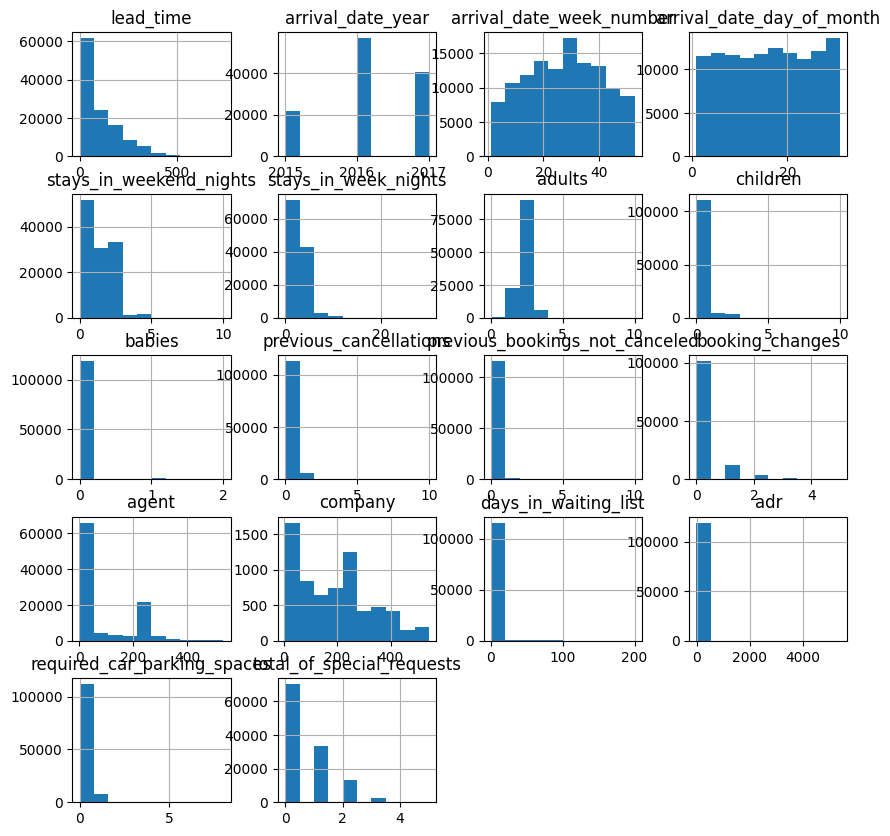

In [116]:
df[numeric_columns].hist(figsize=(10, 10)) 
plt.show() 

### Phân tích hai biến (Bivariate analysis)

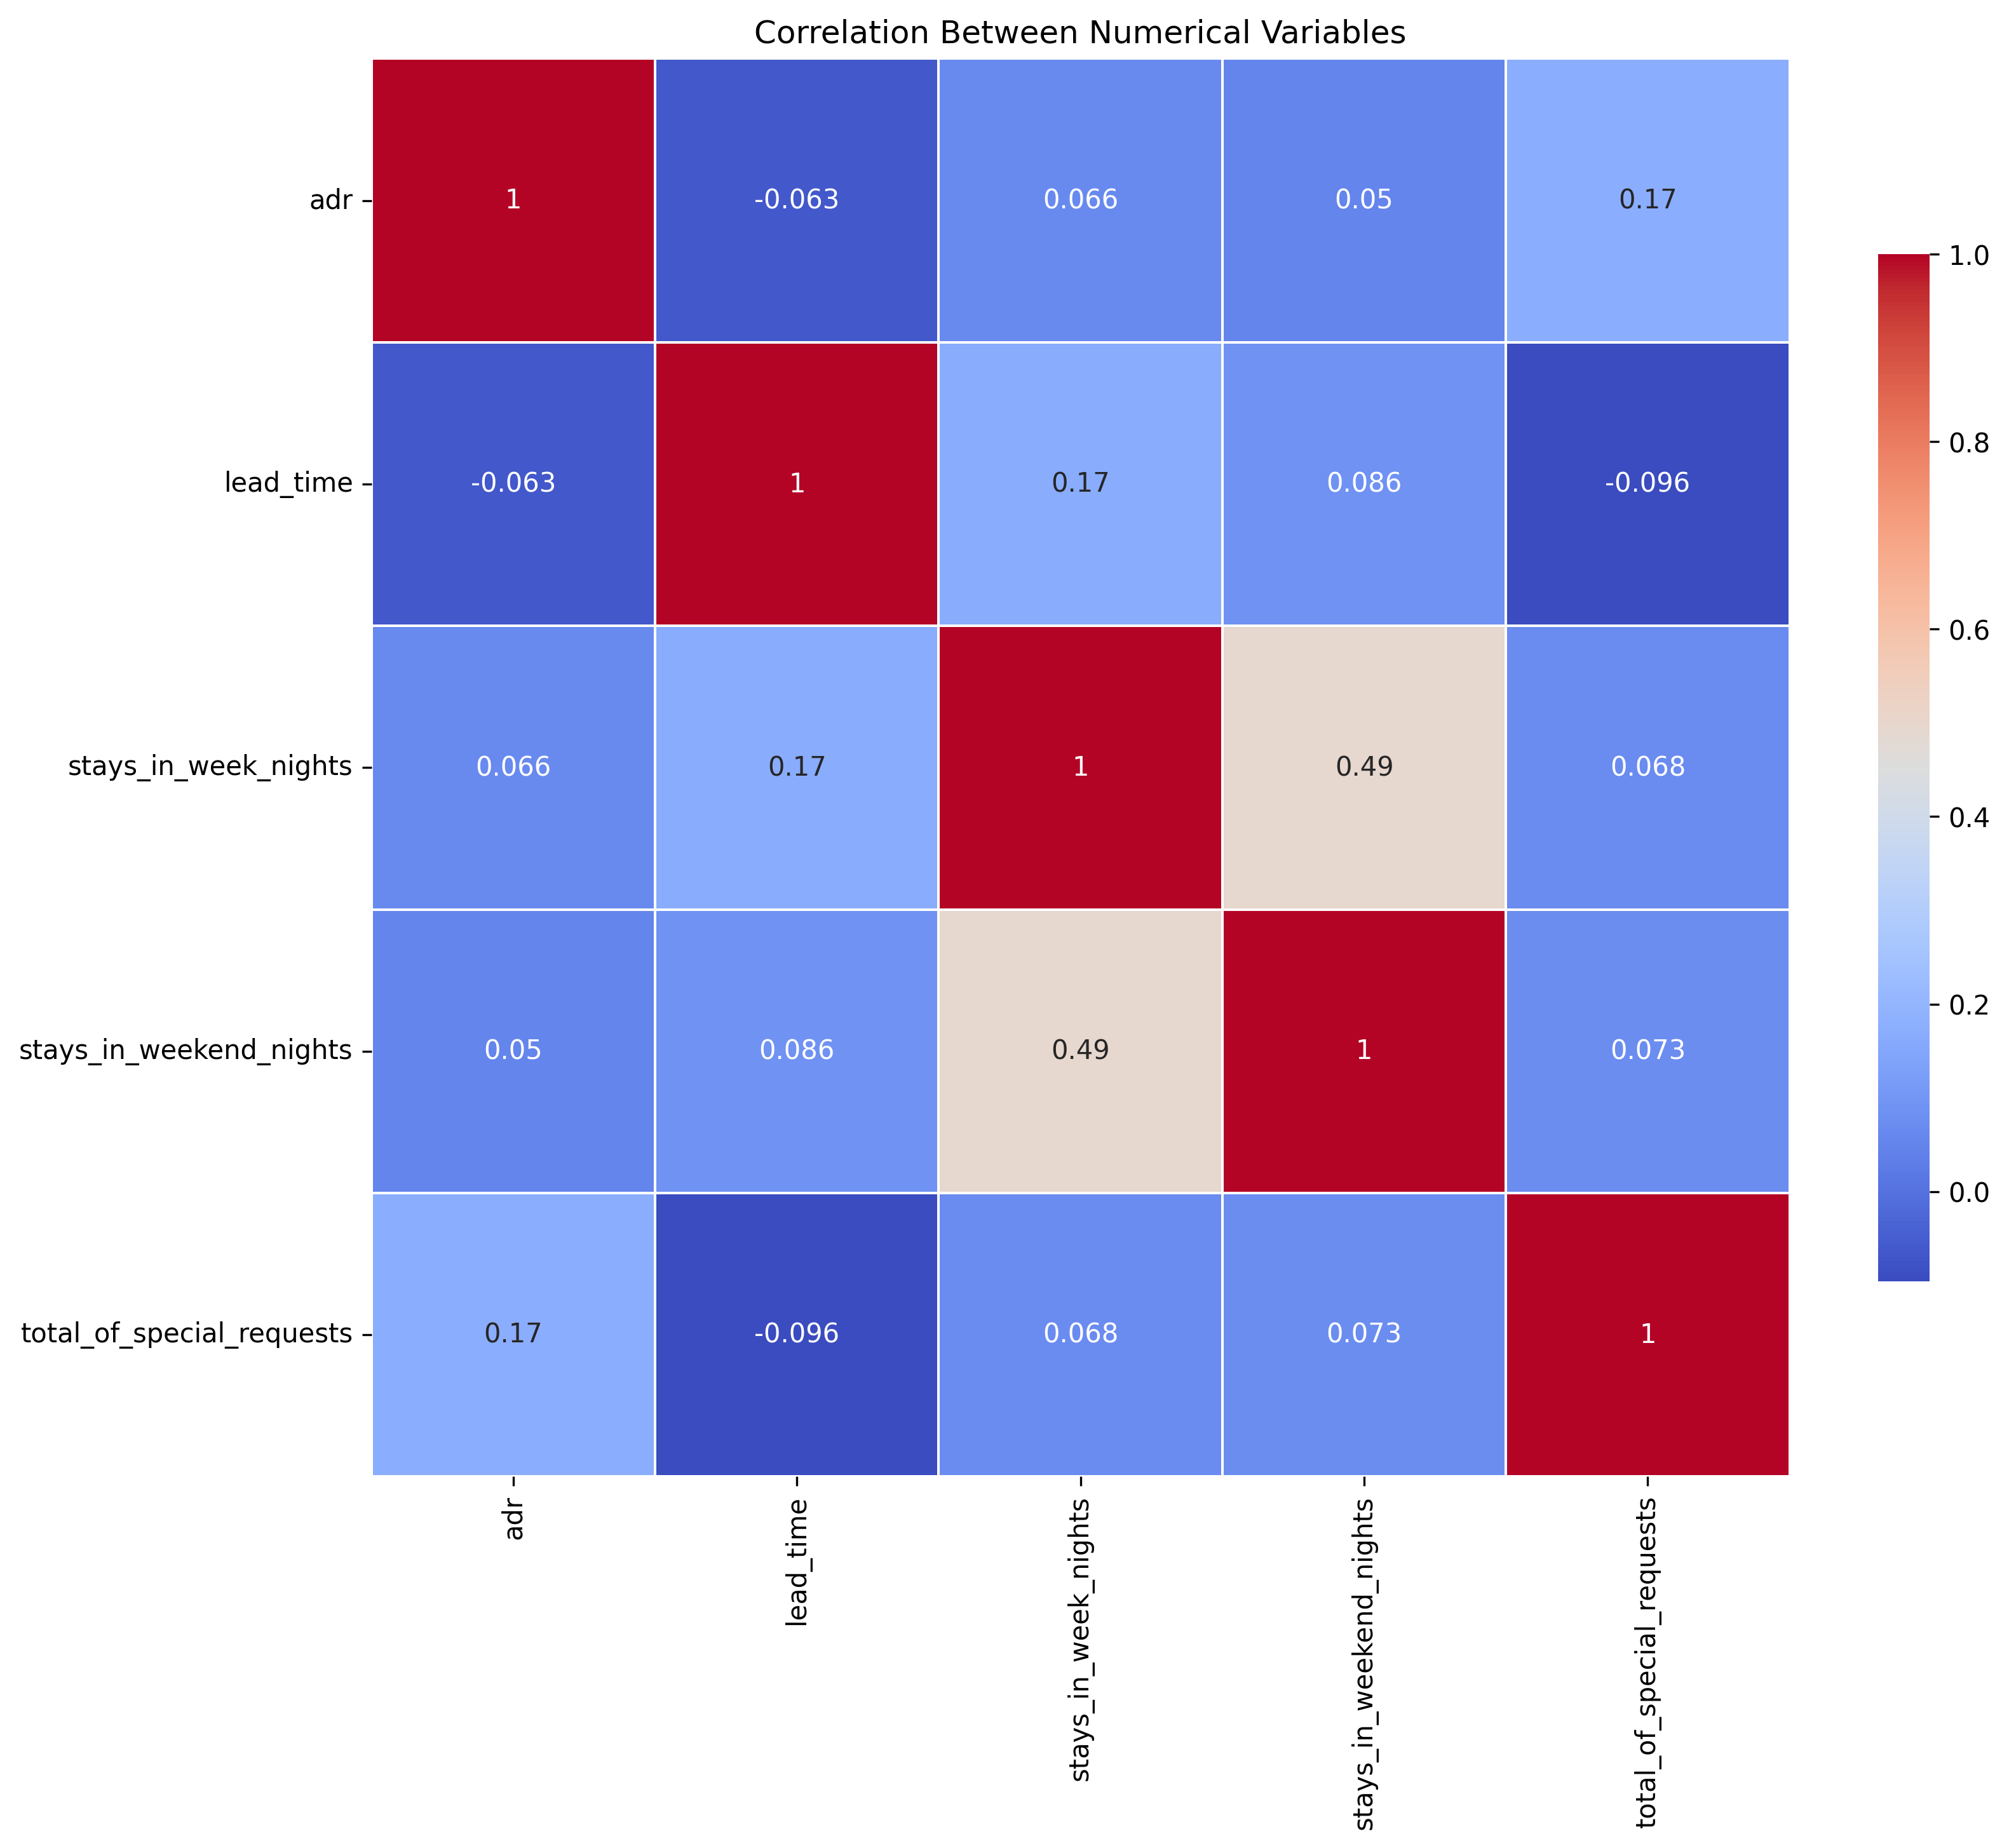

In [117]:

num_cols = ['adr', 'lead_time', 'stays_in_week_nights', 
            'stays_in_weekend_nights', 'total_of_special_requests']
corr = df[num_cols].corr()

plt.figure(figsize=(12, 10), dpi=300)
sns.heatmap(corr, annot=True, cmap='coolwarm', square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Correlation Between Numerical Variables')
plt.show()


##### Kết quả phân tích tương quan cho thấy hầu hết các cặp biến số chỉ có mối quan hệ yếu, nghĩa là hành vi khách không bị chi phối mạnh bởi từng biến riêng lẻ. Tương quan cao nhất là giữa số đêm ở ngày thường và cuối tuần (0.49), cho thấy khách ở lâu thường vào dịp nghỉ cuối tuần. Giá phòng (ADR) có mối liên hệ nhẹ với số yêu cầu đặc biệt (0.17), cho thấy rằng khách hàng phân khúc cao hơn có xu hướng sử dụng thêm dịch vụ – phù hợp để triển khai chiến lược marketing cao cấp.

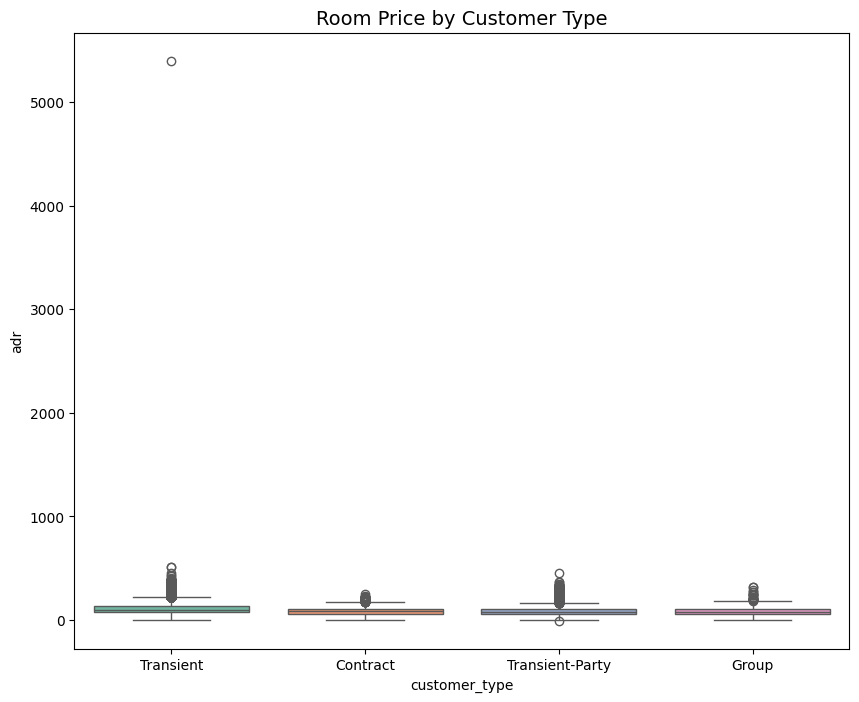

customer_type
Group               85.261788
Transient-Party     86.092889
Contract            87.549637
Transient          107.013872
Name: adr, dtype: float64


In [118]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='customer_type', y='adr', hue='customer_type', data=df, palette='Set2')
plt.title("Room Price by Customer Type", fontsize=14)

plt.show()

df.groupby('customer_type')['adr'].mean().sort_values()

# Hiển thị giá trị trung bình ADR theo loại khách hàng
print(df.groupby('customer_type')['adr'].mean().sort_values())


#### Nhận xét
- Khách đặt phòng đơn lẻ, không theo đoàn, không hợp đồng. Đây là dạng khách phổ biến nhất – khách du lịch, công tác tự book, là phân khúc có khả năng chi trả cao nhất, xuất hiện nhiều booking với ADR cao → là đối tượng quảng cáo, upsell và dịch vụ cao cấp.
- Nhóm đoàn lớn – tour du lịch, hội nghị, sự kiện, công ty du lịch dẫn đoàn và Khách theo hợp đồng công ty, đại lý, doanh nghiệp: khách đi công việc, nhân sự công ty, đại lý gửi khách có ADR thấp → phù hợp khuyến mãi theo số lượng, combo.
- Khách lẻ theo nhóm nhỏ (gia đình, bạn bè) có tiềm năng trung bình, có thể target theo du lịch gia đình, bạn bè.



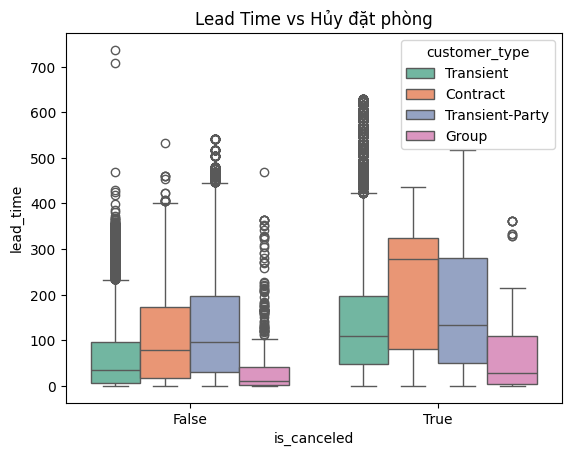

In [119]:
# Mối quan hệ giữa lead_time và is_canceled
df_cleaned = df
sns.boxplot(x='is_canceled', y='lead_time', hue='customer_type', data=df_cleaned, palette='Set2')
plt.title("Lead Time vs Hủy đặt phòng")
plt.show()


#### Nhận xét:
Biểu đồ cho thấy lead_time của các đặt phòng bị hủy cao hơn đáng kể so với các đặt phòng giữ nguyên. Điều này chứng minh rằng khách đặt phòng từ rất sớm có xu hướng thay đổi kế hoạch và hủy nhiều hơn. Đây là bằng chứng để khách sạn áp dụng chính sách đặt cọc hoặc ưu đãi giữ phòng cho các booking có lead_time dài.



## Tiền xử lý dữ liệu

### Xử lí missing value

In [120]:
# Xử lý company trước
if 'company' in df.columns:
    missing_pct = df['company'].isnull().sum() / len(df)
    if missing_pct > 0.9:
        print(f"Xóa cột 'company' (thiếu {missing_pct*100:.1f}%)")
        df = df.drop('company', axis=1)
    else:
        df['company'] = df['company'].fillna(0)

# Điền giá trị thiếu - KHÔNG dùng inplace=True
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['agent'] = df['agent'].fillna(0)

# Kiểm tra kết quả
print(f"Tổng giá trị thiếu còn lại: {df.isnull().sum().sum()}")

Xóa cột 'company' (thiếu 94.3%)
Tổng giá trị thiếu còn lại: 0


In [121]:
print(df.isnull().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

### Xử lý dữ liệu trùng lặp


In [122]:
# Xóa trùng lặp
df_cleaned = df.drop_duplicates()

# Kiểm tra lại
print(f"Số hàng trùng còn lại: {df_cleaned.duplicated().sum()}")

# Xem thông tin DataFrame sau khi làm sạch
print(df_cleaned.info())

Số hàng trùng còn lại: 0
<class 'pandas.core.frame.DataFrame'>
Index: 87347 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87347 non-null  object 
 1   is_canceled                     87347 non-null  bool   
 2   lead_time                       87347 non-null  int64  
 3   arrival_date_year               87347 non-null  int64  
 4   arrival_date_month              87347 non-null  object 
 5   arrival_date_week_number        87347 non-null  int64  
 6   arrival_date_day_of_month       87347 non-null  int64  
 7   stays_in_weekend_nights         87347 non-null  int64  
 8   stays_in_week_nights            87347 non-null  int64  
 9   adults                          87347 non-null  int64  
 10  children                        87347 non-null  float64
 11  babies                          87347 non-null  int64  
 12  meal       

In [123]:
df_cleaned = df.drop_duplicates(keep='first')
print(f"Số hàng trước khi xóa trùng lặp: {len(df)} hàng")
print(f"Số hàng sau khi xóa trùng lặp: {len(df_cleaned)} hàng")
print(f"Đã xóa: {len(df) - len(df_cleaned)} hàng")

Số hàng trước khi xóa trùng lặp: 119372 hàng
Số hàng sau khi xóa trùng lặp: 87347 hàng
Đã xóa: 32025 hàng


### Xử lý outlier


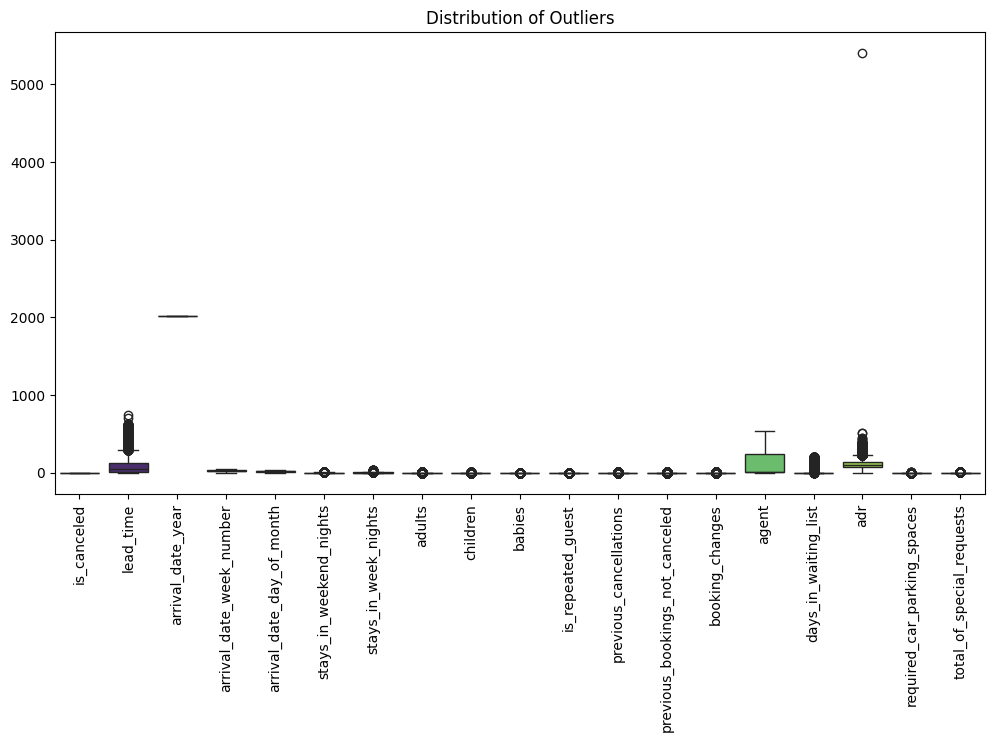

In [124]:
#BOX PLOT TRƯỚC KHI XỬ LÍ 
plt.figure(figsize=(12,6))
sns.boxplot(data=df_cleaned, palette='viridis')
plt.title('Distribution of Outliers')
plt.xticks(rotation=90)
plt.show()

In [125]:
print("Thống kê mô tả của dữ liệu trước khi xử lý outlier:")
print(df_cleaned.describe())

Thống kê mô tả của dữ liệu trước khi xử lý outlier:
          lead_time  arrival_date_year  arrival_date_week_number  \
count  87347.000000       87347.000000              87347.000000   
mean      79.874237        2016.210517                 26.837613   
std       86.005383           0.685986                 13.673555   
min        0.000000        2015.000000                  1.000000   
25%       11.000000        2016.000000                 16.000000   
50%       49.000000        2016.000000                 27.000000   
75%      125.000000        2017.000000                 37.000000   
max      737.000000        2017.000000                 53.000000   

       arrival_date_day_of_month  stays_in_weekend_nights  \
count               87347.000000             87347.000000   
mean                   15.816330                 1.004660   
std                     8.834868                 1.023945   
min                     1.000000                 0.000000   
25%                     8.0000

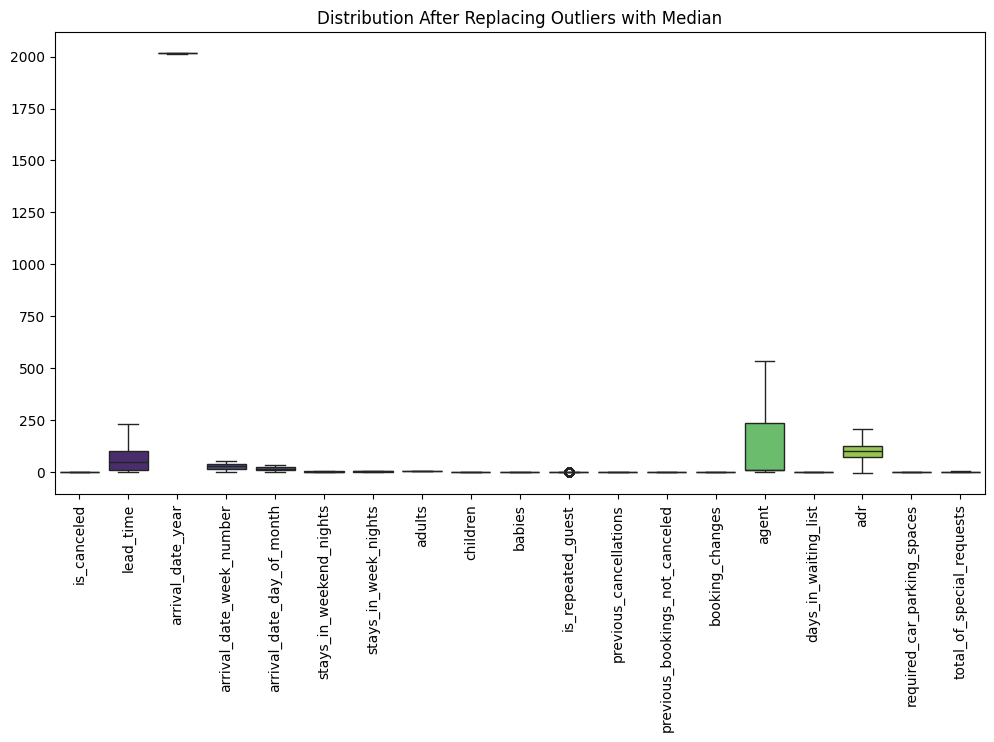

Thống kê mô tả sau khi thay thế outliers:
          lead_time  arrival_date_year  arrival_date_week_number  \
count  87347.000000       87347.000000              87347.000000   
mean      62.942253        2016.210517                 26.837613   
std       60.974826           0.685986                 13.673555   
min        0.000000        2015.000000                  1.000000   
25%       11.000000        2016.000000                 16.000000   
50%       49.000000        2016.000000                 27.000000   
75%       99.000000        2017.000000                 37.000000   
max      231.000000        2017.000000                 53.000000   

       arrival_date_day_of_month  stays_in_weekend_nights  \
count               87347.000000             87347.000000   
mean                   15.816330                 0.989170   
std                     8.834868                 0.973887   
min                     1.000000                 0.000000   
25%                     8.000000        

In [126]:

# --- HÀM THAY OUTLIER BẰNG TRUNG VỊ ---
def replace_outliers_with_median(df):
    df_cleaned = df.copy()  # tránh sửa trực tiếp dữ liệu gốc
    for column in df_cleaned.select_dtypes(include=[np.number]).columns:
        while True:
            q1 = df_cleaned[column].quantile(0.25)
            q3 = df_cleaned[column].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            
            # Xác định outlier
            outliers = (df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)
            
            # Nếu không còn outlier thì thoát vòng lặp
            if not outliers.any():
                break
            
            # Thay thế bằng trung vị
            median = df_cleaned[column].median()
            df_cleaned.loc[outliers, column] = median
    return df_cleaned

# --- GỌI HÀM ---
df_no_outlier = replace_outliers_with_median(df_cleaned)

# --- XÁC NHẬN KẾT QUẢ ---
plt.figure(figsize=(12,6))
sns.boxplot(data=df_no_outlier, palette='viridis')
plt.title('Distribution After Replacing Outliers with Median')
plt.xticks(rotation=90)
plt.show()

# --- THỐNG KÊ TÓM TẮT SAU KHI XỬ LÝ ---
print("Thống kê mô tả sau khi thay thế outliers:")
print(df_no_outlier.describe())


### Xử lý ngoại lệ và giá trị bất thường trong dữ liệu đặt phòng:

- **Stays in Week Nights:** Quan sát có giá trị >50 đêm. Xử lý bằng cách giới hạn tối đa 30 đêm và có thể phân loại ngắn/trung/dài.  
- **Stays in Weekend Nights:** Quan sát có giá trị >17 đêm. Giới hạn tối đa 10 đêm.  
- **Adults, Children, Babies:** Quan sát có giá trị bất thường (adults >50, children >10). Lọc các giá trị không hợp lý (adults ≤10, children ≤10, babies ≤5) và điền giá trị thiếu (children = median, babies = 0).  
- **Previous Cancellations & Previous Bookings Not Canceled:** Quan sát có giá trị >20. Giới hạn tối đa 10, đồng thời phân tích các trường hợp hủy/đặt nhiều.  
- **Booking Changes:** Một số booking có >10 thay đổi. Giới hạn tối đa 5 và kiểm tra nguyên nhân các booking thay đổi nhiều.  
- **Days in Waiting List:** Quan sát có giá trị >300 ngày. Giới hạn tối đa 200 ngày và phân loại ngắn/trung/dài cho phân tích.

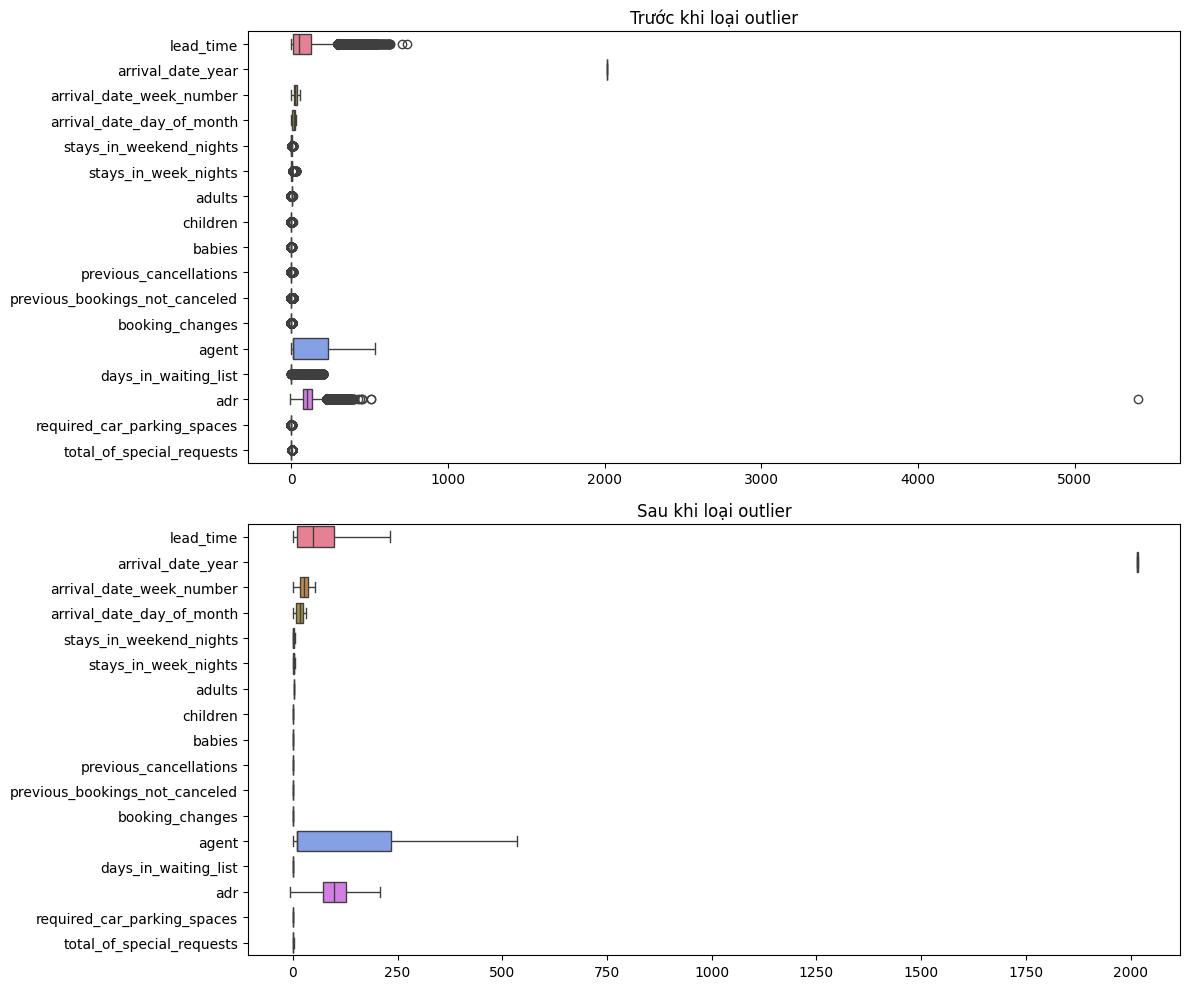

In [127]:
# trực quan lại trước và sau xử lý outlier
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12,10))
plt.subplot(2,1,1)
sns.boxplot(data=df_cleaned[numeric_cols], orient='h')
plt.title("Trước khi loại outlier")

plt.subplot(2,1,2)
sns.boxplot(data=df_no_outlier[numeric_cols], orient='h')
plt.title("Sau khi loại outlier")

plt.tight_layout()
plt.show()


In [128]:
df_no_outlier.to_csv('hotel_booking_cleaned.csv', index=False)
print("Kiểm tra kích thước và các giá trị sau xử lý:")
print(df_no_outlier.shape)
print(df_no_outlier.describe())


Kiểm tra kích thước và các giá trị sau xử lý:
(87347, 31)
          lead_time  arrival_date_year  arrival_date_week_number  \
count  87347.000000       87347.000000              87347.000000   
mean      62.942253        2016.210517                 26.837613   
std       60.974826           0.685986                 13.673555   
min        0.000000        2015.000000                  1.000000   
25%       11.000000        2016.000000                 16.000000   
50%       49.000000        2016.000000                 27.000000   
75%       99.000000        2017.000000                 37.000000   
max      231.000000        2017.000000                 53.000000   

       arrival_date_day_of_month  stays_in_weekend_nights  \
count               87347.000000             87347.000000   
mean                   15.816330                 0.989170   
std                     8.834868                 0.973887   
min                     1.000000                 0.000000   
25%                     

In [129]:
data_model = df_no_outlier

In [130]:

# Giữ lại các cột có thông tin hành vi khách hàng
features = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
    'total_of_special_requests', 'is_repeated_guest',
    'deposit_type', 'customer_type', 'market_segment',
    'distribution_channel', 'reserved_room_type',
    'assigned_room_type', 'meal', 'hotel'
]

df_model = data_model[features].copy()

# Mã hóa các cột phân loại (label encoding)
label_cols = [
    'deposit_type', 'customer_type', 'market_segment',
    'distribution_channel', 'reserved_room_type',
    'assigned_room_type', 'meal', 'hotel'
]

le = LabelEncoder()
for col in label_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("Dữ liệu sau khi mã hóa:")
print(df_model.head(3))


Dữ liệu sau khi mã hóa:
   lead_time  stays_in_weekend_nights  stays_in_week_nights  adults  children  \
0         49                        0                     0       2       0.0   
1         49                        0                     0       2       0.0   
2          7                        0                     1       2       0.0   

   babies  previous_cancellations  previous_bookings_not_canceled  \
0       0                       0                               0   
1       0                       0                               0   
2       0                       0                               0   

   booking_changes  days_in_waiting_list  ...  total_of_special_requests  \
0                0                     0  ...                          0   
1                0                     0  ...                          0   
2                0                     0  ...                          0   

   is_repeated_guest  deposit_type  customer_type  market_segment  \


In [131]:
# Chuẩn hóa
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_model[numeric_cols])

print("Đã chuẩn hóa dữ liệu xong (StandardScaler).")

Đã chuẩn hóa dữ liệu xong (StandardScaler).


In [132]:
#Giảm chiều
pca = PCA(n_components=10, random_state=42)
data_pca = pca.fit_transform(scaled_data)

In [133]:
# Chuyển ndarray → DataFrame
data_pca_df = pd.DataFrame(data_pca, columns=[f'PC{i+1}' for i in range(data_pca.shape[1])])

# Lưu ra file CSV
data_pca_df.to_csv('hotel_booking_after_pca.csv', index=False)

print("Đã lưu file PCA thành công: hotel_booking_after_pca.csv")
print("Kích thước dữ liệu:", data_pca_df.shape)

Đã lưu file PCA thành công: hotel_booking_after_pca.csv
Kích thước dữ liệu: (87347, 10)


In [134]:
data_pca_df.to_csv('hotel_booking_after_pca.csv', index=False)
print("Kiểm tra kích thước và các giá trị sau tiền xử lý:")
print(data_pca_df.shape)
print(data_pca_df.describe())


Kiểm tra kích thước và các giá trị sau tiền xử lý:
(87347, 10)
                PC1           PC2           PC3           PC4           PC5  \
count  8.734700e+04  8.734700e+04  8.734700e+04  8.734700e+04  8.734700e+04   
mean   7.809324e-17 -4.164973e-17 -2.082486e-17 -5.987148e-17  2.863419e-17   
std    1.296956e+00  1.238547e+00  1.085652e+00  9.987665e-01  9.930155e-01   
min   -2.971682e+00 -3.229250e+00 -4.063688e+00 -3.066941e+00 -2.829454e+00   
25%   -9.699721e-01 -1.009253e+00 -7.445697e-01 -7.082036e-01 -7.167029e-01   
50%   -1.298149e-01  1.882751e-01 -2.710831e-04  1.983796e-03 -6.873088e-02   
75%    8.423538e-01  9.715038e-01  7.595634e-01  7.492371e-01  6.564955e-01   
max    5.676644e+00  2.681405e+00  3.723378e+00  2.580787e+00  4.215279e+00   

                PC6           PC7           PC8           PC9          PC10  
count  8.734700e+04  8.734700e+04  8.734700e+04  8.734700e+04  8.734700e+04  
mean   4.002279e-17 -5.726838e-17 -3.123730e-17 -5.206216e-18  1.0837

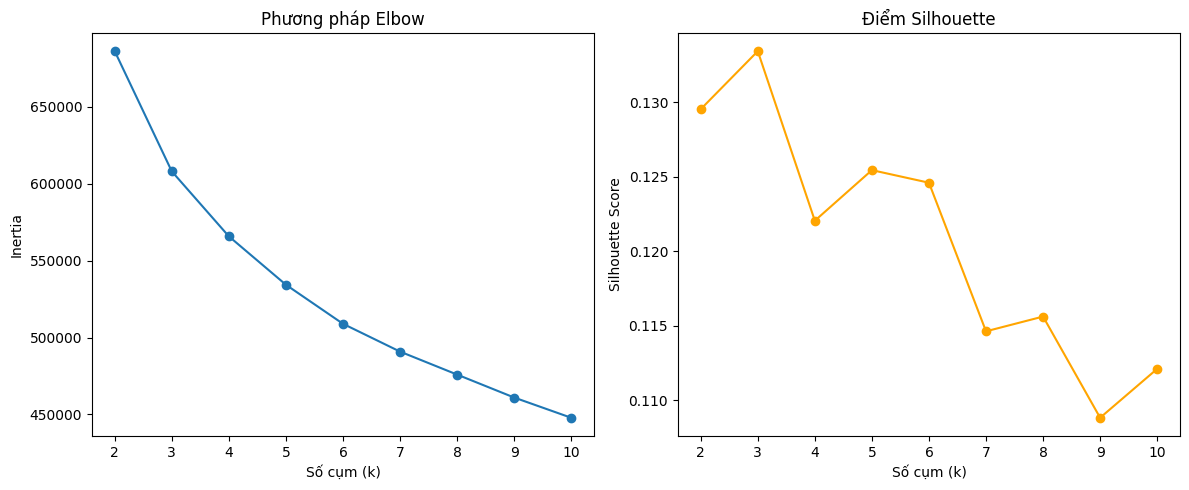

In [135]:
inertias, silhouette_scores = [], []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data_pca, kmeans.labels_))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertias, marker='o')
plt.title("Phương pháp Elbow")
plt.xlabel("Số cụm (k)")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o', color='orange')
plt.title("Điểm Silhouette")
plt.xlabel("Số cụm (k)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


In [136]:
# --- Bước 1: Tạo bản sao dữ liệu PCA để lưu kết quả cụm ---
dt_pca = data_pca_df.copy()

# --- Bước 2: Chạy KMeans ---
optimal_k = 3  # Dựa theo biểu đồ Elbow & Silhouette
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Gán nhãn cụm vào DataFrame
dt_pca['Cluster'] = kmeans.fit_predict(data_pca_df)

print("Đã gán nhãn cụm cho dữ liệu.")
print(dt_pca['Cluster'].value_counts())

# --- Bước 3: Đặt tên cho cụm (tùy số lượng cụm bạn có) ---
cluster_names = {
    0: 'Khách chi tiêu thấp',
    1: 'Khách chi tiêu trung bình',
    2: 'Khách đặt sớm, chi tiêu cao'
}

dt_pca['Cluster_Name'] = dt_pca['Cluster'].map(cluster_names)

# --- Bước 4: Xem thử dữ liệu sau khi gán tên cụm ---
print("\nXem ví dụ dữ liệu sau khi thêm tên cụm:")
print(dt_pca[['Cluster', 'Cluster_Name']].head())


Đã gán nhãn cụm cho dữ liệu.
Cluster
1    35803
2    26390
0    25154
Name: count, dtype: int64

Xem ví dụ dữ liệu sau khi thêm tên cụm:
   Cluster                 Cluster_Name
0        2  Khách đặt sớm, chi tiêu cao
1        2  Khách đặt sớm, chi tiêu cao
2        2  Khách đặt sớm, chi tiêu cao
3        2  Khách đặt sớm, chi tiêu cao
4        2  Khách đặt sớm, chi tiêu cao


Đã thêm cột 'Cluster' từ dt_pca vào data_model.

Tóm tắt cụm khách hàng:
            adr        lead_time stays_in_week_nights stays_in_weekend_nights  \
           mean  count      mean                 mean                    mean   
Cluster                                                                         
0.0       85.48  18241     55.86                 2.43                    1.02   
1.0       94.48  24050     56.00                 2.39                    1.03   
2.0      101.92  18337     75.18                 2.61                    1.10   

        total_of_special_requests  
                             mean  
Cluster                            
0.0                          0.54  
1.0                          0.55  
2.0                          0.54  
Đã tạo tạm cột 'Cluster_Name' để hiển thị trên biểu đồ.


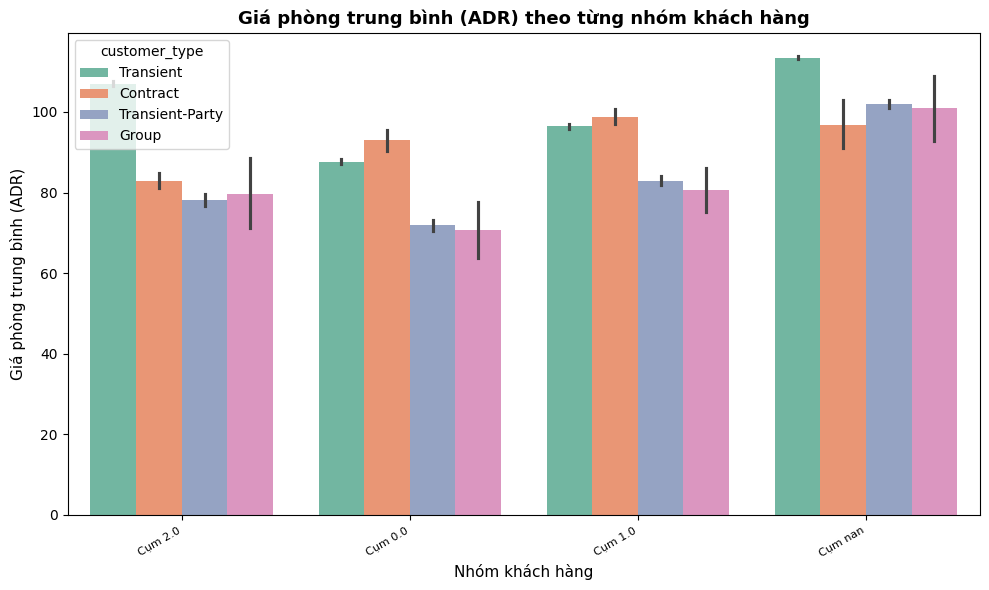

In [137]:
# Kiểm tra xem có cột 'Cluster' chưa
if 'Cluster' not in data_model.columns:
    if 'dt_pca' in globals() and 'Cluster' in dt_pca.columns:
        data_model['Cluster'] = dt_pca['Cluster']
        print("Đã thêm cột 'Cluster' từ dt_pca vào data_model.")
    else:
        raise ValueError("Không tìm thấy cột 'Cluster' trong data_model hoặc dt_pca!")

# Kiểm tra các cột cần thiết trước khi groupby
cols_needed = ['adr', 'lead_time', 'stays_in_week_nights', 'stays_in_weekend_nights', 'total_of_special_requests']
cols_exist = [col for col in cols_needed if col in data_model.columns]
missing_cols = [col for col in cols_needed if col not in data_model.columns]

if missing_cols:
    print(f"Cảnh báo: Các cột sau không tồn tại trong data_model và sẽ bị bỏ qua: {missing_cols}")

# Tạo dict aggregation chỉ với cột có tồn tại
agg_dict = {}
if 'adr' in cols_exist:
    agg_dict['adr'] = ['mean', 'count']
for col in cols_exist:
    if col != 'adr':
        agg_dict[col] = 'mean'

# Thực hiện groupby
cluster_summary = data_model.groupby('Cluster').agg(agg_dict).round(2)

print("\nTóm tắt cụm khách hàng:")
print(cluster_summary)

# --- BIỂU ĐỒ TRỰC QUAN HÓA ADR ---
# Kiểm tra Cluster_Name, nếu chưa có thì tạo tạm
if 'Cluster_Name' not in data_model.columns:
    unique_clusters = sorted(data_model['Cluster'].unique())
    data_model['Cluster_Name'] = data_model['Cluster'].map({c: f'Cụm {c}' for c in unique_clusters})
    print("Đã tạo tạm cột 'Cluster_Name' để hiển thị trên biểu đồ.")

# Vẽ biểu đồ ADR
if 'adr' in cols_exist:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Cluster_Name', y='adr', hue='customer_type', data=data_model, palette='Set2')
    plt.title("Giá phòng trung bình (ADR) theo từng nhóm khách hàng", fontsize=13, fontweight='bold')
    plt.xlabel("Nhóm khách hàng", fontsize=11)
    plt.ylabel("Giá phòng trung bình (ADR)", fontsize=11)
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Không thể vẽ biểu đồ vì cột 'adr' không tồn tại trong data_model.")


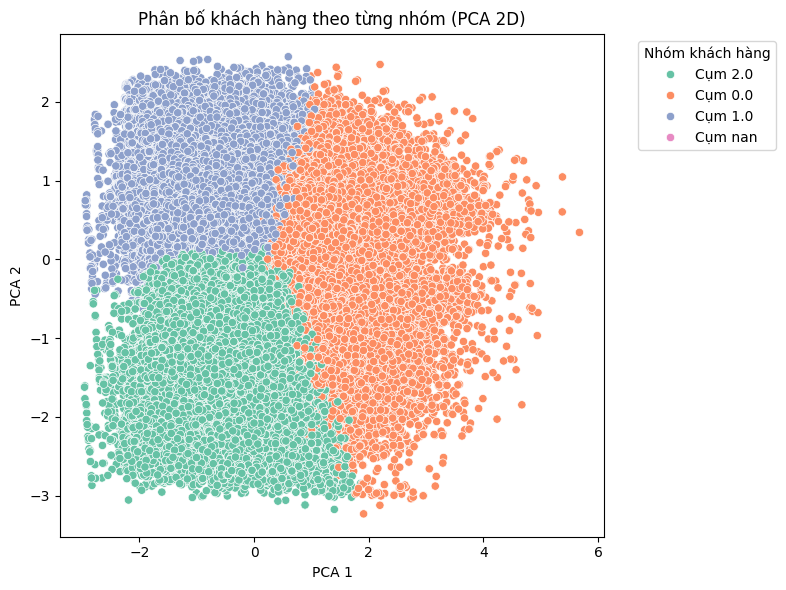

In [138]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=dt_pca.iloc[:, 0], 
    y=dt_pca.iloc[:, 1], 
    hue=data_model['Cluster_Name'], 
    palette='Set2'
)
plt.title("Phân bố khách hàng theo từng nhóm (PCA 2D)")
plt.legend(title="Nhóm khách hàng", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()
